## Imports

In [6]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor
import numpy as np
import shap
from sklearn.linear_model import Ridge
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import seaborn as sns

In [7]:
df = pd.read_csv("ML_dataset2.csv")

In [8]:
df.head()

,Country,Year,Precipitation,River Flow,Soil Water,Surface Water,Terr Water Storage,Vegetation Avg,Water Bodies,Avg Temp,Water Stress,Population Growth,Freshwater Resources,GDP,Overall Water Withdrawals,Dom Wuthdrawls,Political Violence
0,Algeria,2001,52.0,22.998,0.100000,NaN,NaN,0.117250,2099.032,24.18333,81.71,1.373291,358.971009,1776.949446,51.633028,31.40793,155.0
1,Algeria,2002,61.0,20.755,0.103333,NaN,-1.000000,0.115583,1835.018,23.87500,85.04,1.330395,354.226905,1751.911234,53.735272,31.96875,210.0
2,Algeria,2003,99.0,23.075,0.107500,0.000121,2.333333,0.120667,2119.552,23.85833,87.52,1.329615,349.548223,1793.094603,55.305819,32.48746,158.0
3,Algeria,2004,94.0,21.668,0.107500,0.000125,3.000000,0.122333,2149.398,23.51667,90.01,1.396440,344.700914,2116.689481,56.876366,32.96862,96.0
4,Algeria,2005,73.0,21.193,0.105833,0.000080,-6.500000,0.120083,1926.585,23.88333,92.49,1.463309,339.693600,2627.289243,58.446912,33.41618,78.0


## Initial Data Cleaning

Cleaning up the data, "Water Stress" had an asterisk while other features contained whitespace. Further, changed "Eswatini (formerly Swaziland)" to "Eswatini" and dropped any rows that were completely empty.

In [9]:
df.columns = df.columns.str.strip()

df["Country"] = df["Country"].str.replace(
    "Eswatini (formerly Swaziland)", "Eswatini"
)

df["Water Stress"] = (
    df["Water Stress"]
    .astype(str)
    .str.replace("*", "", regex=False)
    .str.strip()
    .replace(["", "nan", "None"], pd.NA)
)

df = df.dropna(how="all")
df = df.rename(columns={"Dom Wuthdrawls": "Dom Withdrawals"})

## Final Train/Test Split

Created a final train/test split that is completely untouched besides basic data cleaning.

In [10]:
FINAL_TEST_YEAR = 2024

test_df = df[df["Year"] == FINAL_TEST_YEAR].copy()
train_df = df[df["Year"] < FINAL_TEST_YEAR].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (1242, 17)
Test shape: (54, 17)


## EDA

Begin to visualize data, observing relationships and patterns across different features. Below shows Angola's precipitation over time, trending downward.

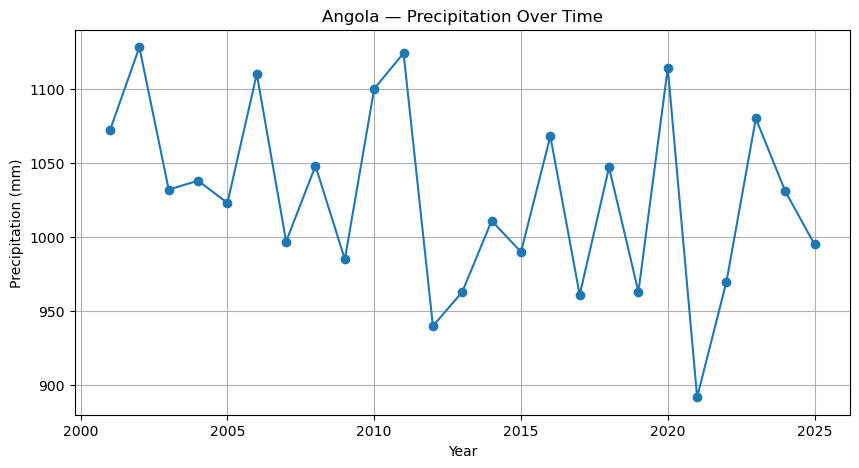

In [11]:
angola = df[df["Country"]=="Angola"]
plt.figure(figsize=(10,5))
plt.plot(angola["Year"], angola["Precipitation"], marker="o")
plt.title("Angola — Precipitation Over Time")
plt.xlabel("Year")
plt.ylabel("Precipitation (mm)")
plt.grid(True)
plt.show()

Logging water stress so that it fit the scale as the range of water stress was very high. From this graph, it was observed that water stress is very high when a country has almost no rain. Once a country experiences rain however, water stress significantly decreases.

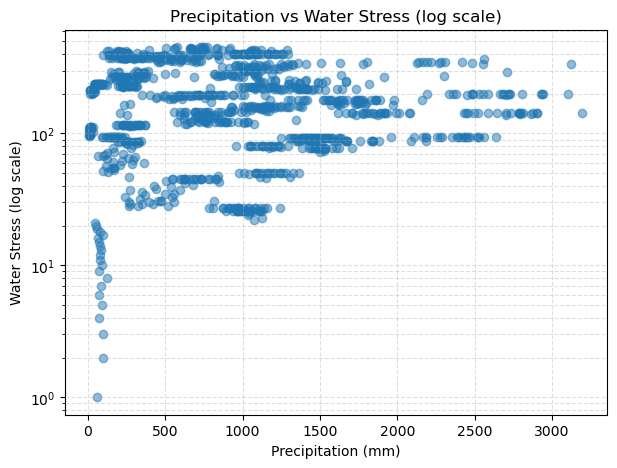

In [12]:
scatter_df = df[["Precipitation", "Water Stress"]].dropna()

plt.figure(figsize=(7,5))
plt.scatter(scatter_df["Precipitation"], scatter_df["Water Stress"], alpha=0.5)
plt.yscale("log")
plt.title("Precipitation vs Water Stress (log scale)")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Water Stress (log scale)")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.show()


Observing patterns between average temperature and precipitation showing a potential slight exponential/parabolic trend.

C:\Users\sidne\AppData\Local\Temp\ipykernel_14784\3946385391.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scatter_df["Avg Temp"] = pd.to_numeric(scatter_df["Avg Temp"], errors="coerce")
C:\Users\sidne\AppData\Local\Temp\ipykernel_14784\3946385391.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scatter_df["Precipitation"] = pd.to_numeric(scatter_df["Precipitation"], errors="coerce")


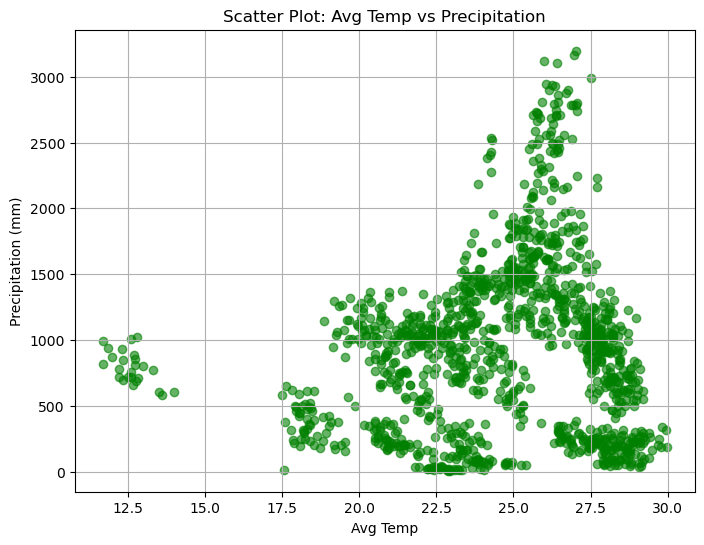

In [13]:
scatter_df = df.dropna(subset=["Avg Temp", "Precipitation"])

scatter_df["Avg Temp"] = pd.to_numeric(scatter_df["Avg Temp"], errors="coerce")
scatter_df["Precipitation"] = pd.to_numeric(scatter_df["Precipitation"], errors="coerce")

plt.figure(figsize=(8,6))
plt.scatter(scatter_df["Avg Temp"], scatter_df["Precipitation"], c='green', alpha=0.6)
plt.xlabel("Avg Temp")
plt.ylabel("Precipitation (mm)")
plt.title("Scatter Plot: Avg Temp vs Precipitation")
plt.grid(True)
plt.show()

## Further Cleaning

Below the cleaning continued. The numeric_cols defines which columns need to be numeric, before cleaning each of them. From here, the cleaning was applied to the train and test set separately.

In [14]:
numeric_cols = [
    "Precipitation", "River Flow", "Soil Water", "Surface Water",
    "Terr Water Storage", "Avg Temp", "Vegetation Avg", "Water Bodies",
    "Population Growth", "GDP", "Political Violence"
]

def clean_numeric(df, cols):
    for col in cols:
        df[col] = (
            df[col].astype(str)
                   .str.replace(",", "", regex=False)
                   .str.replace("*", "", regex=False)
                   .str.strip()
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

train_df = clean_numeric(train_df, numeric_cols)
test_df  = clean_numeric(test_df, numeric_cols)

The vars_to_interp selects the features that can be interpolated. They are all hydrology variables and over time change smoothly. Hence, we can interpolate values within each country without risking the authenticity of our data.

Next, we sort by country and year to ensure that the interpolation happens in chronological order. From here we interpolate and fill any remaining NaNS with median values.

In [15]:
vars_to_interp = [
    "Precipitation", "River Flow", "Soil Water", "Surface Water",
    "Terr Water Storage", "Avg Temp", "Vegetation Avg", "Water Bodies"
]

train_df = train_df.sort_values(["Country", "Year"])

for col in vars_to_interp:
    train_df[col] = (
        train_df.groupby("Country")[col]
                .apply(lambda x: x.interpolate(method="linear", limit_direction="both"))
                .reset_index(level=0, drop=True)
    )

train_df[vars_to_interp] = (
    train_df.groupby("Country")[vars_to_interp]
            .transform(lambda x: x.fillna(x.median()))
)

Next, we define the columns we want to keep and subset the training and testing data to avoid leakage.

In [16]:
keep_cols = [
    "Country", "Year",
    "Precipitation", "River Flow", "Soil Water", "Surface Water",
    "Terr Water Storage", "Vegetation Avg", "Water Bodies",
    "Avg Temp", "Population Growth", "GDP", "Political Violence"
]

train_df = train_df[keep_cols].copy()
test_df  = test_df[keep_cols].copy()

## Initial Modelling Attempt (Water Stress)

First attempt to model water stress. Set water stress as the first target.

In [17]:
ws_numeric_cols = [
    "Precipitation", "River Flow", "Soil Water", "Surface Water",
    "Terr Water Storage", "Avg Temp", "Vegetation Avg", "Water Bodies",
    "Population Growth", "GDP", "Political Violence", "Water Stress"
]

ws_df = df[df["Year"] < FINAL_TEST_YEAR].copy()
ws_df = clean_numeric(ws_df, ws_numeric_cols)
ws_df = ws_df.sort_values(["Country", "Year"])

for col in vars_to_interp:
    ws_df[col] = (
        ws_df.groupby("Country")[col]
             .apply(lambda x: x.interpolate(method="linear", limit_direction="both"))
             .reset_index(level=0, drop=True)
    )

ws_df[vars_to_interp] = (
    ws_df.groupby("Country")[vars_to_interp]
         .transform(lambda x: x.fillna(x.median()))
)

features_ws = [
    "Country", "Year",
    "Precipitation", "River Flow", "Soil Water", "Surface Water",
    "Terr Water Storage", "Avg Temp",
    "Vegetation Avg", "Water Bodies",
    "Population Growth", "GDP", "Political Violence"
]

target_ws = "Water Stress"

ws_df = ws_df.dropna(subset=features_ws + [target_ws])

## Baseline Linear Regression



In [18]:
X_ws = ws_df[features_ws]
y_ws = ws_df[target_ws]

numeric_features = X_ws.select_dtypes(include=["float64", "int64"]).columns
categorical_features = X_ws.select_dtypes(include=["object"]).columns

preprocess_ws = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

pipe_lr_ws = Pipeline(steps=[
    ("preprocess", preprocess_ws),
    ("model", LinearRegression())
])

results_lr = []
years = sorted(ws_df["Year"].unique())

for test_year in years:
    if test_year <= 2005:
        continue

    train = ws_df[ws_df["Year"] < test_year]
    test  = ws_df[ws_df["Year"] == test_year]

    if len(test) == 0:
        continue

    X_train = train[features_ws]
    y_train = train[target_ws]

    X_test = test[features_ws]
    y_test = test[target_ws]

    pipe_lr_ws.fit(X_train, y_train)
    preds = pipe_lr_ws.predict(X_test)

    rmse = mean_squared_error(y_test, preds) ** 0.5
    r2 = r2_score(y_test, preds)

    results_lr.append({
        "Test Year": test_year,
        "RMSE": rmse,
        "R2": r2
    })

results_lr_df = pd.DataFrame(results_lr)
results_lr_df

,Test Year,RMSE,R2
0,2006,12.143135,0.991186
1,2007,11.269789,0.992764
2,2008,9.731566,0.994852
3,2009,7.677024,0.996940
4,2010,14.368580,0.989752
5,2011,12.943502,0.992042
6,2012,19.521604,0.982629
7,2013,20.014116,0.981449
8,2014,15.023900,0.989560
9,2015,16.520476,0.987327


This showed an immediate red flag. Low RMSE and high R^2 showed hinted that there must be some kind of leakage issue or poor data.

## XGBoost

Trying XGBoost to see if anything changes. Chose XGBoost because it works well with tabular data and can handle non-linear relationships as well as missing values. Given that some of our features had numerous missing values that didn't make sense to fill, XGBoost seemed like a good fit.

In [19]:
categorical = ["Country"]
numeric = [col for col in features_ws if col not in categorical]

preprocess_ws = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
        ("num", "passthrough", numeric)
    ]
)


xgb_ws = XGBRegressor(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)


pipeline_ws = Pipeline(steps=[
    ("preprocess", preprocess_ws),
    ("model", xgb_ws)
])

results_ws = []
years = sorted(ws_df["Year"].unique())

for test_year in years:
    if test_year <= 2005:
        continue

    train = ws_df[ws_df["Year"] < test_year]
    val   = ws_df[ws_df["Year"] == test_year]

    if len(val) == 0:
        continue

    X_train = train[features_ws]
    y_train = train[target_ws]

    X_val = val[features_ws]
    y_val = val[target_ws]

    pipeline_ws.fit(X_train, y_train)
    preds = pipeline_ws.predict(X_val)

    rmse = mean_squared_error(y_val, preds) ** 0.5
    r2 = r2_score(y_val, preds)

    results_ws.append({"Test Year": test_year, "RMSE": rmse, "R2": r2})

results_ws_df = pd.DataFrame(results_ws)
results_ws_df


,Test Year,RMSE,R2
0,2006,24.485831,0.964161
1,2007,14.697922,0.987692
2,2008,5.997995,0.998044
3,2009,7.911929,0.996750
4,2010,9.910379,0.995125
5,2011,15.165317,0.989076
6,2012,16.078717,0.988216
7,2013,15.782744,0.988464
8,2014,5.834843,0.998425
9,2015,11.712053,0.993630


Again, like our baseline test, our results were too good. Below shows a comparison of the actual vs predicted value and as can be seen, the model was very accurate.

In [20]:
print(f"\n Predictions for {test_year}")
print(pd.DataFrame({
    "Country": val["Country"].values,
    "Actual": y_val.values,
    "Predicted": preds
}))


 Predictions for 2023
         Country  Actual   Predicted
0          Egypt  141.17  141.717773
1       Ethiopia   32.26   30.903599
2          Ghana    6.31    7.790759
3         Guinea    1.37    1.641547
4          Kenya   33.24   31.534590
5        Liberia    0.26    0.177221
6          Libya  817.14  817.713684
7     Madagascar   11.26   11.628893
8         Malawi   17.50   19.509758
9           Mali    8.00    8.368169
10       Morocco   50.75   40.063564
11    Mozambique    1.75    2.413704
12       Namibia    0.31    1.682521
13         Niger   11.02   10.872108
14        Rwanda   20.20   20.323339
15       Senegal   16.28   16.132607
16  Sierra Leone    0.50    0.503710
17  South Africa   67.60   66.260872
18         Sudan  118.66  111.837357
19          Togo    3.39    3.310609
20        Uganda    5.83    5.891029
21        Zambia    2.84    3.021519
22      Zimbabwe   46.09   40.608589


XGBoost model is essentially memorising each country's Water Stress value. Hence, R^2 is very high but the result here is essentially redundant. This is confirmed in the Feature Importance Below.

Decided to do feature importance to determine how water stress was being so accurately predicted. Feature Importance for Water Stress:

In [21]:
X_ws = ws_df[features_ws]
y_ws = ws_df["Water Stress"]

pipeline_ws.fit(X_ws, y_ws)

model = pipeline_ws.named_steps["model"]
preprocess = pipeline_ws.named_steps["preprocess"]

cat_features = preprocess.named_transformers_["cat"].get_feature_names_out(["Country"])
numeric_feature_names = preprocess.transformers_[1][2]

all_feature_names = list(cat_features) + list(numeric_feature_names)

importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance_df)

                 Feature    Importance
12         Country_Libya  8.920143e-01
37        Vegetation Avg  8.072710e-02
38          Water Bodies  1.322977e-02
25         Country_Sudan  3.861781e-03
31         Precipitation  1.406991e-03
5           Country_Chad  1.074816e-03
36              Avg Temp  9.725693e-04
20        Country_Rwanda  9.674425e-04
16       Country_Morocco  8.595162e-04
7       Country_Ethiopia  8.356317e-04
33            Soil Water  7.003121e-04
23  Country_South Africa  6.566301e-04
29      Country_Zimbabwe  5.862892e-04
39     Population Growth  5.576758e-04
10         Country_Kenya  2.544513e-04
30                  Year  2.523835e-04
21       Country_Senegal  1.513358e-04
34         Surface Water  1.303014e-04
18       Country_Namibia  1.194113e-04
32            River Flow  1.158782e-04
15          Country_Mali  1.084167e-04
35    Terr Water Storage  1.083450e-04
17    Country_Mozambique  9.527319e-05
41    Political Violence  4.148861e-05
3   Country_Burkina Faso 

This shows that the country itself was hugely important in determining water stress. This made sense as the water stress data was incredibly stable. Although it was from a reliable source, it is not always easy to collect and does not always change much. This because a big limitation and turning point in our project.

## Remove Country Feature

Since Water Stress can be predicted very easily through the country feature, we now remove it.

In [22]:
target_ws = "Water Stress"

features_ws_nocountry = [
    "Year",
    "Precipitation", "River Flow", "Soil Water", "Surface Water",
    "Terr Water Storage", "Avg Temp",
    "Vegetation Avg", "Water Bodies",
    "Population Growth", "GDP", "Political Violence"
]

numeric = features_ws_nocountry

In [23]:
preprocess_nocountry = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric)
    ]
)

model_ws_nocountry = XGBRegressor(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

pipeline_ws_nocountry = Pipeline(steps=[
    ("preprocess", preprocess_nocountry),
    ("model", model_ws_nocountry)
])

results = []
years = sorted(ws_df["Year"].unique())

for test_year in years:
    if test_year <= 2005:
        continue

    train = ws_df[ws_df["Year"] < test_year]
    test = ws_df[ws_df["Year"] == test_year]

    if len(test) == 0:
        continue

    X_train = train[features_ws_nocountry]
    y_train = train[target_ws]

    X_test = test[features_ws_nocountry]
    y_test = test[target_ws]

    pipeline_ws_nocountry.fit(X_train, y_train)
    preds = pipeline_ws_nocountry.predict(X_test)

    rmse = mean_squared_error(y_test, preds) ** 0.5
    r2 = r2_score(y_test, preds)

    results.append({
        "Test Year": test_year,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results)
print(results_df)

    Test Year       RMSE        R2
0        2006  86.204830  0.555792
1        2007  20.403532  0.976281
2        2008  15.441881  0.987037
3        2009  10.157171  0.994643
4        2010  21.494053  0.977067
5        2011  23.174926  0.974489
6        2012  20.933903  0.980025
7        2013  14.743052  0.989934
8        2014  12.733468  0.992501
9        2015  16.925326  0.986698
10       2016  10.212429  0.995161
11       2017   8.662624  0.996628
12       2018   7.259548  0.997651
13       2019   9.568629  0.995918
14       2020   4.547778  0.999079
15       2021   8.189959  0.997004
16       2022   8.241831  0.996969
17       2023   5.226373  0.998999


Water Stress' stability means that even after removing country, it is still very easy to predict. Below, the feature importance shows that 'Vegetation Avg' is now the best predictor, followed by Water Bodies.

In [24]:
pipeline_ws_nocountry.fit(ws_df[features_ws_nocountry], ws_df[target_ws])

model = pipeline_ws_nocountry.named_steps["model"]
feature_names = features_ws_nocountry

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance_df)

               Feature  Importance
7       Vegetation Avg    0.674398
8         Water Bodies    0.197733
4        Surface Water    0.061654
1        Precipitation    0.040978
2           River Flow    0.013522
6             Avg Temp    0.004149
3           Soil Water    0.003229
9    Population Growth    0.002305
0                 Year    0.001101
11  Political Violence    0.000425
5   Terr Water Storage    0.000394
10                 GDP    0.000112


## Feature Engineer Water Stress

Here we try and feature engineer our own water stress value to remove the stability we have in our current water stress feature.

In [25]:
ws2 = ws_df.copy()

ws2["WS_custom"] = (
    ws2["Overall Water Withdrawals"] /
    ws2["Freshwater Resources"]
)

ws2["WS_custom_log"] = np.log1p(ws2["WS_custom"])

ws2 = ws2.drop(columns=["Water Stress"], errors="ignore")

target = "WS_custom_log"

We had to log transform as our water stress value was heavily skewed, because most countries withdraw a lot less than their limit while a few countries withdraw far more. This creates a right skew. Further, to avoid collinearity the features used to create our water stress value were removed.

In [26]:
remove = [
    "WS_custom", "WS_custom_log",
    "Overall Water Withdrawals",
    "Freshwater Resources"
]

features = [
    col for col in ws2.columns
    if col not in remove and ws2[col].dtype != "object"
]

In [27]:
preprocess_nocountry = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric)
    ]
)

model_ws_nocountry = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

pipeline_ws_nocountry = Pipeline(steps=[
    ("preprocess", preprocess_nocountry),
    ("model", model_ws_nocountry)
])


results = []
years = sorted(ws2["Year"].unique())

for test_year in years:
    if test_year <= 2005:
        continue

    train = ws2[ws2["Year"] < test_year].dropna(subset=[target])
    test  = ws2[ws2["Year"] == test_year].dropna(subset=[target])

    if len(test) == 0:
        continue

    X_train = train[features]
    y_train = train[target]

    X_test = test[features]
    y_test = test[target]

    pipeline_ws_nocountry.fit(X_train, y_train)
    preds = pipeline_ws_nocountry.predict(X_test)

    rmse = mean_squared_error(y_test, preds) ** 0.5
    r2 = r2_score(y_test, preds)

    results.append({
        "Test Year": test_year,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results)
print(results_df)

    Test Year      RMSE        R2
0        2006  0.058081  0.997779
1        2007  0.064340  0.997317
2        2008  0.099849  0.993636
3        2009  0.629333  0.750929
4        2010  0.182577  0.979344
5        2011  0.135946  0.988516
6        2012  0.086379  0.995402
7        2013  0.376677  0.912563
8        2014  0.257987  0.957311
9        2015  0.132238  0.988884
10       2016  0.201372  0.974400
11       2017  0.272286  0.957787
12       2018  0.182665  0.981138
13       2019  0.155898  0.986355
14       2020  0.301492  0.949290
15       2021  0.211820  0.975123
16       2022  0.529827  0.845292


Still very easy to predict even with our own
feature engineered target. Visualising feature importance below using SHAP index.

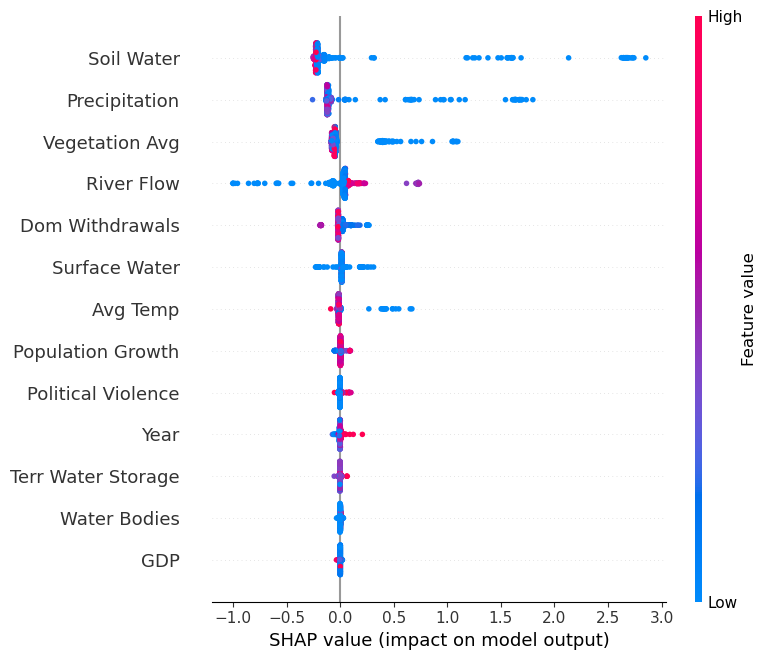

In [28]:
train_all = ws2[ws2["Year"] < 2024].dropna(subset=[target])
X_train_all = train_all[features]
y_train_all = train_all[target]

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb.fit(X_train_all, y_train_all)

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_train_all)

shap.summary_plot(shap_values, X_train_all)


## Creating a Drought Index

Beginning to understand that each hydrological feature is highly correlated, making predictions very easy. Now trying to reduce the amount of leakage present by creating a drought index and making that our target instead.

Standardized drought features and then removed them to reduce leakage.

In [29]:
from sklearn.preprocessing import StandardScaler
di = ws_df.copy()

drought_core = ["Avg Temp", "Precipitation", "Soil Water", "Vegetation Avg"]

scaler_A = StandardScaler()
di[[f"z_{v}" for v in drought_core]] = scaler_A.fit_transform(di[drought_core])

di["DI_A"] = (
    di["z_Avg Temp"]
    - di["z_Precipitation"]
    - di["z_Soil Water"]
    - di["z_Vegetation Avg"]
)

target = "DI_A"

forbidden = [
    "DI_A",
    "z_Avg Temp", "z_Precipitation", "z_Soil Water", "z_Vegetation Avg",
    "Avg Temp", "Precipitation", "Soil Water", "Vegetation Avg"
]
features = [
    c for c in di.columns
    if c not in forbidden and di[c].dtype != "object"
]

Using XGBoost again.

In [30]:
results = []
years = sorted(di["Year"].unique())

for test_year in years:
    if test_year <= 2005:
        continue

    train = di[di["Year"] < test_year].dropna(subset=[target])
    test  = di[di["Year"] == test_year].dropna(subset=[target])

    if len(test) == 0:
        continue

    X_train = train[features]
    y_train = train[target]

    X_test = test[features]
    y_test = test[target]

    reg = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    reg.fit(X_train, y_train)
    preds = reg.predict(X_test)

    rmse = mean_squared_error(y_test, preds) ** 0.5
    r2 = r2_score(y_test, preds)

    results.append({
        "Test Year": test_year,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results)
print(results_df)

    Test Year      RMSE        R2
0        2006  0.760570  0.908191
1        2007  0.522619  0.957714
2        2008  0.445139  0.966450
3        2009  0.573942  0.945502
4        2010  0.909014  0.863618
5        2011  1.040579  0.832965
6        2012  0.874560  0.871314
7        2013  0.654667  0.928389
8        2014  0.451147  0.966515
9        2015  0.455217  0.965448
10       2016  0.396920  0.971563
11       2017  0.676461  0.924645
12       2018  0.443398  0.968801
13       2019  0.510007  0.958121
14       2020  0.367056  0.976570
15       2021  0.470359  0.965135
16       2022  0.638889  0.935670
17       2023  1.202768  0.768067


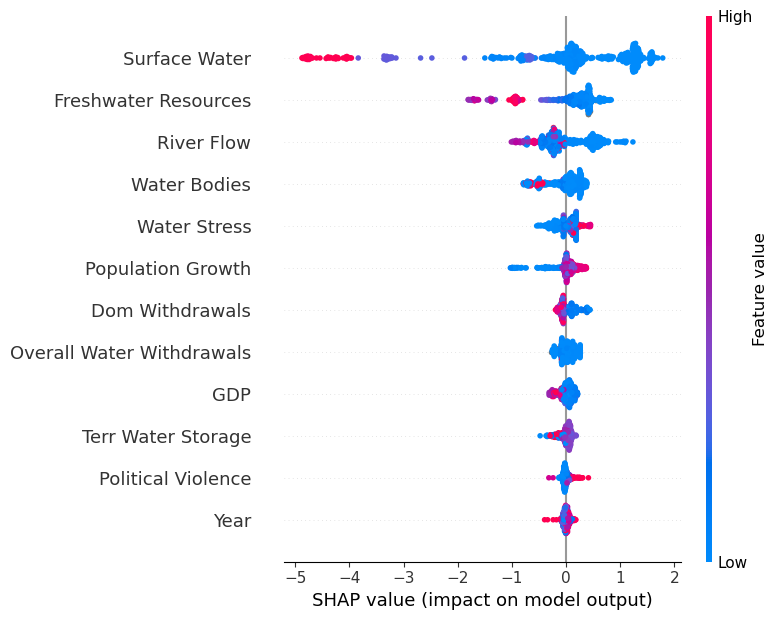

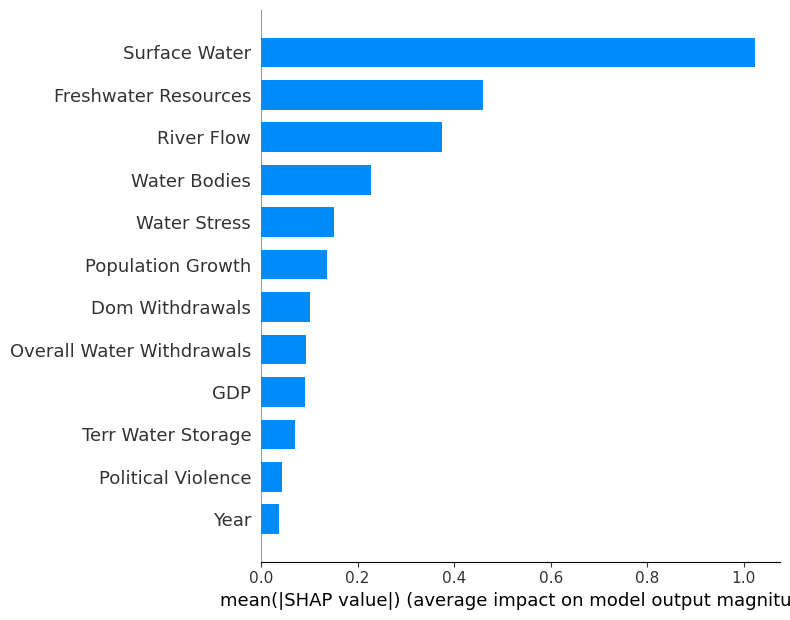

In [31]:
train_all = di[di["Year"] < 2024].dropna(subset=[target])
X_train_all = train_all[features]
y_train_all = train_all[target]

reg.fit(X_train_all, y_train_all)

explainer = shap.TreeExplainer(reg)
shap_values = explainer.shap_values(X_train_all)

shap.summary_plot(shap_values, X_train_all)
shap.summary_plot(shap_values, X_train_all, plot_type="bar")

Clearly, creating our own index only slightly reduces R^2, and not enough to make it less redundant or obvious.

From here, the most logical step was to change the target. We change out target value to population growth. It had the highest importance of all non-hydrological values which clearly we needed to avoid as a target value.

## Changing Target to Population Growth

All Features (except Water Stress). We got rid of water stress as it was too stable and potentially redundant.

In [32]:
pg = ws_df.copy()

target = "Population Growth"

all_features = [
    "Precipitation",
    "Soil Water",
    "Surface Water",
    "River Flow",
    "Terr Water Storage",
    "Vegetation Avg",
    "Water Bodies",
    "Avg Temp",
    "Freshwater Resources",
    "Overall Water Withdrawals",
    "Dom Withdrawals",
    "Industrial Withdrawals",
    "GDP",
    "Political Violence",
    "Year"
]

all_features = [f for f in all_features if f in pg.columns]

pg = pg.dropna(subset=[target])

years = sorted(pg["Year"].unique())


Linear Regression - Baseline

In [33]:
lin_scores = []

for test_year in years:
    if test_year <= 2005:
        continue

    train = pg[pg["Year"] < test_year]
    test  = pg[pg["Year"] == test_year]

    X_train = train[all_features].dropna()
    y_train = train.loc[X_train.index, target]

    X_test = test[all_features].dropna()
    y_test = test.loc[X_test.index, target]

    if len(X_test) == 0:
        continue

    model = LinearRegression()
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    lin_scores.append(r2_score(y_test, preds))

print("Linear Regression average R²:", np.mean(lin_scores))


Linear Regression average R²: 0.12737118823786234


This was a poor result. At least R^2 wasn't almost 1 but clearly Linear Regression did not learn the model well at all. Population growth is driven by nonlinear processes so this result is not surprising. It also can't handle the collinearity of the hydrological features. So next we try ridge regression as it can handle this better.

Ridge Regression

In [34]:

ridge_scores = []

for test_year in years:
    if test_year <= 2005:
        continue

    train = pg[pg["Year"] < test_year]
    test  = pg[pg["Year"] == test_year]

    X_train = train[all_features].dropna()
    y_train = train.loc[X_train.index, target]

    X_test = test[all_features].dropna()
    y_test = test.loc[X_test.index, target]

    if len(X_test) == 0:
        continue

    model = Ridge(alpha=1.0)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    ridge_scores.append(r2_score(y_test, preds))

print("Ridge Regression average R²:", np.mean(ridge_scores))


Ridge Regression average R²: 0.13036566501105532


C:\Users\sidne\anaconda3\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.90186e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\sidne\anaconda3\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.62497e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\sidne\anaconda3\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.32319e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\sidne\anaconda3\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.11403e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\sidne\anaconda3\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.95602e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Us

Still performed poorly as it fixes collinearity but our features are still nonlinear. Next, we move back onto XGBoost as it should be able to handle these issues.

XGBoost

In [35]:
xgb_scores = []

for test_year in years:
    if test_year <= 2005:
        continue

    train = pg[pg["Year"] < test_year]
    test  = pg[pg["Year"] == test_year]

    X_train = train[all_features]
    y_train = train[target]

    X_test = test[all_features]
    y_test = test[target]

    model = XGBRegressor(
        n_estimators=600,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    xgb_scores.append(r2_score(y_test, preds))

print("XGBoost average R²:", np.mean(xgb_scores))


XGBoost average R²: 0.5104375146051999


Cleary there is a big improvement here. LightGBM is slightly faster than XGBoost and has a more expressive boosting algorithm so this was the natural choice to try next.

LightGBM

In [36]:
lgb_scores = []

for test_year in years:
    if test_year <= 2005:
        continue

    train = pg[pg["Year"] < test_year]
    test  = pg[pg["Year"] == test_year]

    X_train = train[all_features]
    y_train = train[target]

    X_test = test[all_features]
    y_test = test[target]

    model = lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    lgb_scores.append(r2_score(y_test, preds))

print("LightGBM average R²:", np.mean(lgb_scores))


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000209 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 579
[LightGBM] [Info] Number of data points in the train set: 138, number of used features: 14
[LightGBM] [Info] Start training from score 2.547790
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

This improved our R^2. Next, we try with only hydrological features.

Next, we try to determine if anything changes if we only keep hydrological variables.

##Removing Water Stress + Hydro Features Only

Linear Regression (Baseline)

In [37]:
hydro_features = [
    "Precipitation",
    "Soil Water",
    "Surface Water",
    "River Flow",
    "Terr Water Storage",
    "Water Bodies",
    "Vegetation Avg",
    "Avg Temp",
    "Freshwater Resources",
    "Year"
]

In [38]:
features = [f for f in hydro_features if f in pg.columns]
pg_model = pg.dropna(subset=[target])
print(features)

['Precipitation', 'Soil Water', 'Surface Water', 'River Flow', 'Terr Water Storage', 'Water Bodies', 'Vegetation Avg', 'Avg Temp', 'Freshwater Resources', 'Year']


In [39]:
lin_scores = []

for test_year in years:
    if test_year <= 2005:
        continue

    train = pg[pg["Year"] < test_year]
    test  = pg[pg["Year"] == test_year]

    X_train = train[hydro_features].dropna()
    y_train = train.loc[X_train.index, target]

    X_test = test[hydro_features].dropna()
    y_test = test.loc[X_test.index, target]

    if len(X_test) == 0:
        continue

    model = LinearRegression()
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    lin_scores.append(r2_score(y_test, preds))

print("Linear Regression average R²:", np.mean(lin_scores))


Linear Regression average R²: 0.20546141002470633


This performs better than previously, suggesting that socioeconomic factors could be adding noise.

Other Models

XGBoost

In [40]:
results = []
years = sorted(pg_model["Year"].unique())

for test_year in years:
    if test_year <= 2005:
        continue

    train = pg_model[pg_model["Year"] < test_year]
    test  = pg_model[pg_model["Year"] == test_year]

    if len(test) == 0:
        continue

    X_train = train[hydro_features]
    y_train = train[target]

    X_test = test[hydro_features]
    y_test = test[target]

    reg = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    reg.fit(X_train, y_train)
    preds = reg.predict(X_test)

    rmse = mean_squared_error(y_test, preds) ** 0.5
    r2 = r2_score(y_test, preds)

    results.append({
        "Test Year": test_year,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results)
results_df

mean_r2 = results_df["R2"].mean()
print("Mean R²:", mean_r2)


Mean R²: 0.6249403585390234


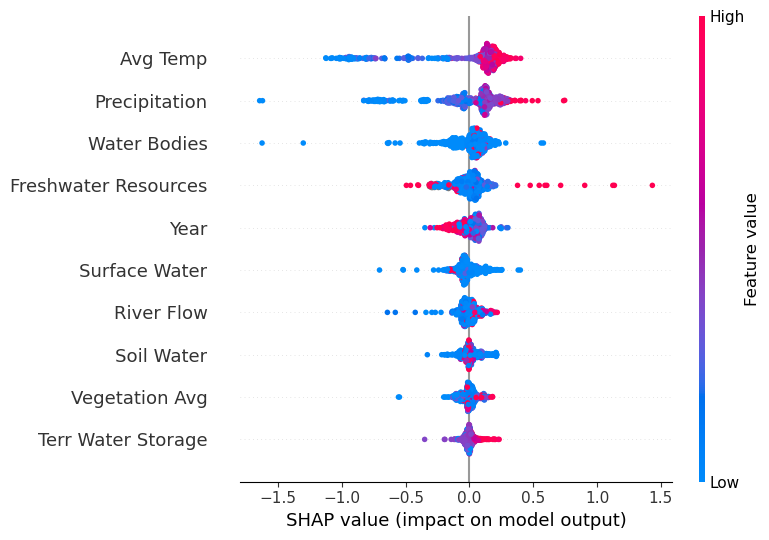

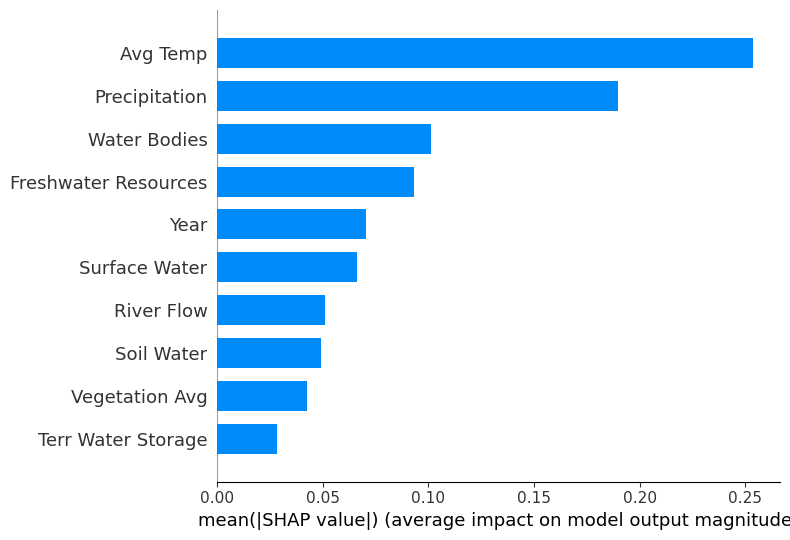

In [41]:
train_all = pg[pg["Year"] < 2024]

X_train_all = train_all[hydro_features]
y_train_all = train_all[target]

xgb = XGBRegressor(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb.fit(X_train_all, y_train_all)

expl_xgb = shap.TreeExplainer(xgb)
shap_xgb = expl_xgb.shap_values(X_train_all)

shap.summary_plot(shap_xgb, X_train_all)
shap.summary_plot(shap_xgb, X_train_all, plot_type="bar")


Interestingly, this increased the R^2. This could potentially signal that certain socioeconomic features are noisy.

Ridge Regression

In [42]:

ridge_scores = []

for test_year in years:
    if test_year <= 2005:
        continue

    train = pg[pg["Year"] < test_year]
    test  = pg[pg["Year"] == test_year]

    X_train = train[hydro_features].dropna()
    y_train = train.loc[X_train.index, target]

    X_test = test[hydro_features].dropna()
    y_test = test.loc[X_test.index, target]

    if len(X_test) == 0:
        continue

    model = Ridge(alpha=1.0)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    ridge_scores.append(r2_score(y_test, preds))

print("Ridge Regression average R²:", np.mean(ridge_scores))


Ridge Regression average R²: 0.2036609339608631


C:\Users\sidne\anaconda3\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.01835e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\sidne\anaconda3\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.76827e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\sidne\anaconda3\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.46052e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\sidne\anaconda3\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.24664e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\sidne\anaconda3\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.0893e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Use

Random Forest

In [43]:

rf_scores = []

for test_year in years:
    if test_year <= 2005:
        continue

    train = pg[pg["Year"] < test_year]
    test  = pg[pg["Year"] == test_year]

    X_train = train[hydro_features].dropna()
    y_train = train.loc[X_train.index, target]

    X_test = test[hydro_features].dropna()
    y_test = test.loc[X_test.index, target]

    if len(X_test) == 0:
        continue

    model = RandomForestRegressor(
        n_estimators=400,
        max_depth=12,
        random_state=42
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    rf_scores.append(r2_score(y_test, preds))

print("Random Forest average R²:", np.mean(rf_scores))



Random Forest average R²: 0.627491834445027


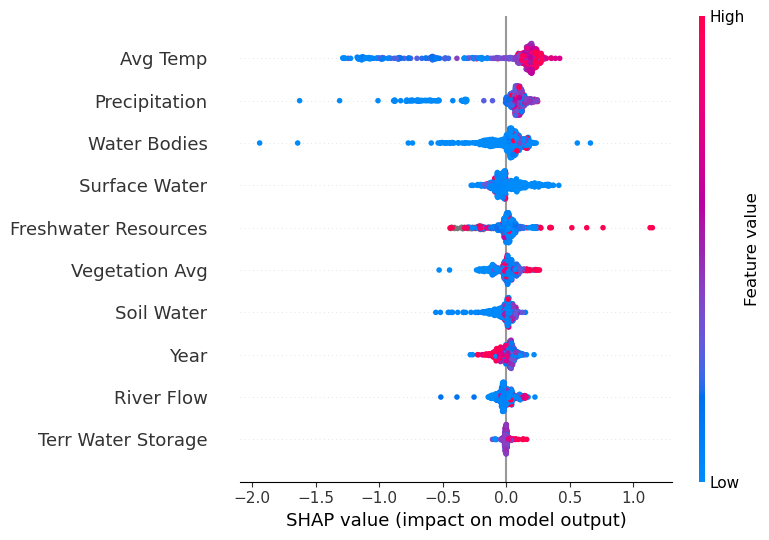

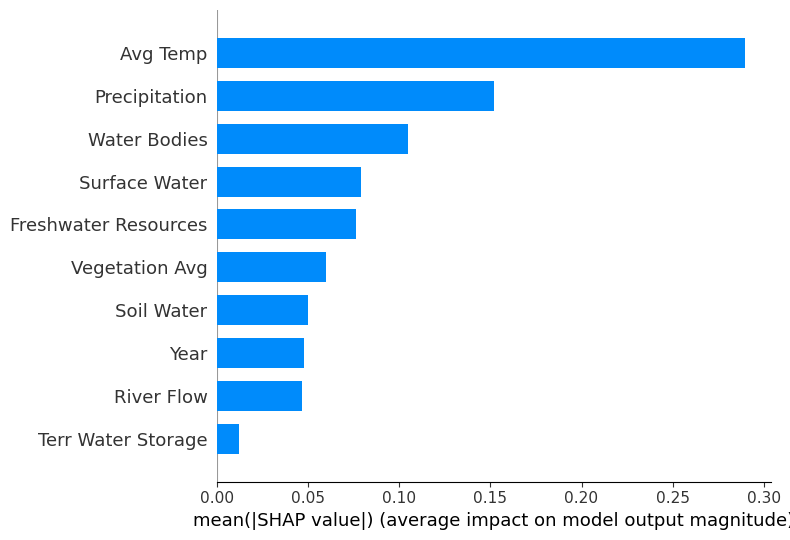

In [44]:
train_all = pg[pg["Year"] < 2024]

X_train_all = train_all[hydro_features]
y_train_all = train_all[target]

rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=12,
    random_state=42
)

rf.fit(X_train_all, y_train_all)

expl_rf = shap.TreeExplainer(rf)
shap_rf = expl_rf.shap_values(X_train_all)

shap.summary_plot(shap_rf, X_train_all)
shap.summary_plot(shap_rf, X_train_all, plot_type="bar")


 LightGBM

In [45]:
lgbm_scores = []

for test_year in years:
    if test_year <= 2005:
        continue

    train = pg[pg["Year"] < test_year]
    test  = pg[pg["Year"] == test_year]

    X_train = train[hydro_features].dropna()
    y_train = train.loc[X_train.index, target]

    X_test = test[hydro_features].dropna()
    y_test = test.loc[X_test.index, target]

    if len(X_test) == 0:
        continue

    lgbm = lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    lgbm.fit(X_train, y_train)
    preds = lgbm.predict(X_test)

    lgbm_scores.append(r2_score(y_test, preds))

print("LightGBM average R²:", np.mean(lgbm_scores))


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000041 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 403
[LightGBM] [Info] Number of data points in the train set: 133, number of used features: 10
[LightGBM] [Info] Start training from score 2.542936
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000085 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1966
[LightGBM] [Info] Number of data points in the train set: 651, number of used features: 10
[LightGBM] [Info] Start training from score 2.521039
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

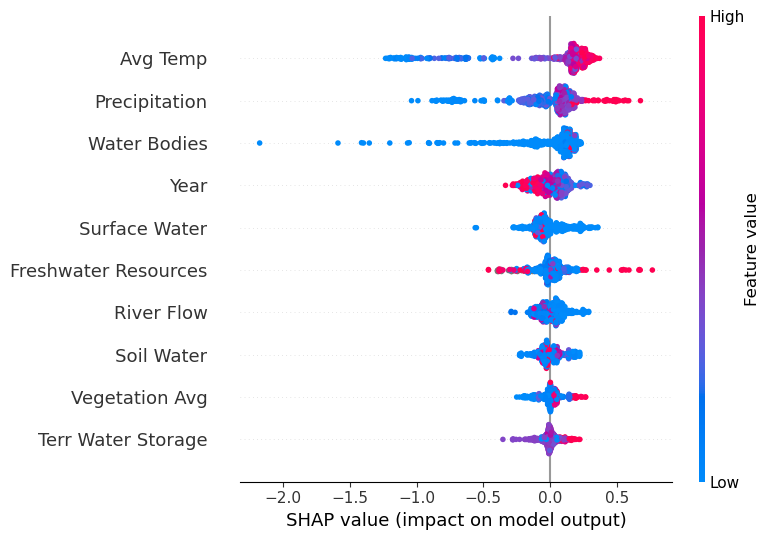

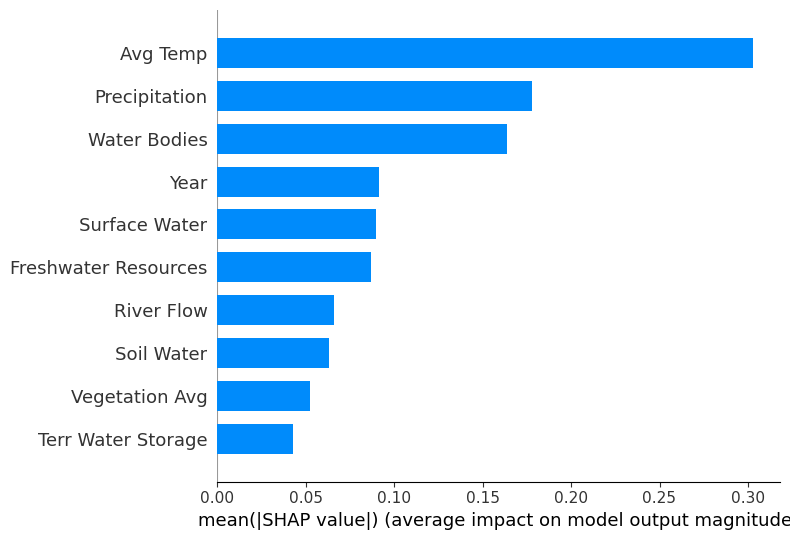

In [46]:
train_all = pg[pg["Year"] < 2024]

X_train_all = train_all[hydro_features]
y_train_all = train_all[target]

lgbm = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm.fit(X_train_all, y_train_all)

expl_lgbm = shap.TreeExplainer(lgbm)
shap_lgbm = expl_lgbm.shap_values(X_train_all)

shap.summary_plot(shap_lgbm, X_train_all)
shap.summary_plot(shap_lgbm, X_train_all, plot_type="bar")



Coefficients for Linear and Ridge

In [47]:
train_all = pg[pg["Year"] < 2024]

X_train_all = train_all[hydro_features].dropna()
y_train_all = train_all.loc[X_train_all.index, target]

ridge_final = Ridge(alpha=1.0)
ridge_final.fit(X_train_all, y_train_all)

lin_final = LinearRegression()
lin_final.fit(X_train_all, y_train_all)


C:\Users\sidne\anaconda3\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.21778e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [48]:
coef_df = pd.DataFrame({
    "feature": hydro_features,
    "coef_linear": lin_final.coef_,
    "coef_ridge": ridge_final.coef_
}).sort_values("coef_ridge", key=abs, ascending=False)

coef_df


,feature,coef_linear,coef_ridge
2,Surface Water,8.090932e-01,4.520949e-01
1,Soil Water,-1.171693e-01,-1.041268e-01
7,Avg Temp,9.567779e-02,9.447559e-02
6,Vegetation Avg,2.182192e-02,2.298290e-02
9,Year,-1.297740e-02,-1.332079e-02
0,Precipitation,4.210478e-04,4.334243e-04
4,Terr Water Storage,4.054633e-05,5.899464e-05
3,River Flow,1.682459e-05,1.666030e-05
8,Freshwater Resources,-1.423197e-05,-1.493842e-05
5,Water Bodies,-1.482368e-08,-6.509003e-09


From these coefficients we can see that there is very little linear predictive power for population growth from hydrological features.

Dropping 2020/2021

In [49]:
pg_clean = pg[(pg["Year"] != 2020) & (pg["Year"] != 2021)]


Retry XGBoost

In [50]:

xgb_scores = []

for test_year in years:
    if test_year <= 2005:
        continue

    train = pg_clean[pg_clean["Year"] < test_year]
    test  = pg_clean[pg_clean["Year"] == test_year]

    X_train = train[hydro_features]
    y_train = train[target]

    X_test = test[hydro_features]
    y_test = test[target]

    if len(X_test) == 0:
        continue

    model = XGBRegressor(
        n_estimators=600,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    xgb_scores.append(r2_score(y_test, preds))

print("XGBoost average R²:", np.mean(xgb_scores))


XGBoost average R²: 0.613438077489946


Retry LightGBM

In [51]:
lgbm_scores = []

for test_year in years:
    if test_year <= 2005:
        continue

    train = pg_clean[pg_clean["Year"] < test_year]
    test  = pg_clean[pg_clean["Year"] == test_year]

    X_train = train[hydro_features].dropna()
    y_train = train.loc[X_train.index, target]

    X_test = test[hydro_features].dropna()
    y_test = test.loc[X_test.index, target]

    if len(X_test) == 0:
        continue

    lgbm = lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    lgbm.fit(X_train, y_train)
    preds = lgbm.predict(X_test)

    lgbm_scores.append(r2_score(y_test, preds))

print("LightGBM average R²:", np.mean(lgbm_scores))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000038 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 403
[LightGBM] [Info] Number of data points in the train set: 133, number of used features: 10
[LightGBM] [Info] Start training from score 2.542936
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

## Binning and Changing to Classification

Since population growth is given as an annual percentage, we create the following bins (including negative growth)

In [52]:
bins = [-3, 0, 2, 3, 4, 6]
labels = ["Negative Grwoth", "Low Growth", "Medium Growth", "High Growth", "Very High Growth"]

In [53]:
pg["target_class"] = pd.cut(
    pg["Population Growth"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

Random Forest

In [54]:


rf_scores = []

years = sorted(pg["Year"].unique())

for test_year in years:
    if test_year <= 2005:
        continue

    train = pg[pg["Year"] < test_year]
    test  = pg[pg["Year"] == test_year]

    X_train = train[hydro_features].dropna()
    y_train = train.loc[X_train.index, "target_class"]

    X_test = test[hydro_features].dropna()
    y_test = test.loc[X_test.index, "target_class"]

    if len(X_test) == 0:
        continue

    model = RandomForestClassifier(
        n_estimators=400,
        max_depth=12,
        random_state=42
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    rf_scores.append(accuracy_score(y_test, preds))

print("RF Classification Accuracy:", np.mean(rf_scores))


RF Classification Accuracy: 0.8762382347575045


This unsurprisingly worked very well. We decided however our goal was regression and not classification.

##Improving R^2

Incorporating Alejandro's use of creating a Population Lag.

In [55]:
target = "Population Growth"

pg_clean = pg_clean.sort_values(["Country", "Year"])

for col in hydro_features:
    pg_clean[f"{col}_lag1"] = pg_clean.groupby("Country")[col].shift(1)
    pg_clean[f"{col}_lag2"] = pg_clean.groupby("Country")[col].shift(2)
    pg_clean[f"{col}_lag3"] = pg_clean.groupby("Country")[col].shift(3)

for col in hydro_features:
    pg_clean[f"{col}_roll3"] = pg_clean.groupby("Country")[col].transform(
        lambda x: x.shift(1).rolling(3).mean()
    )

lag_cols = (
    [f"{col}_lag1" for col in hydro_features] +
    [f"{col}_lag2" for col in hydro_features] +
    [f"{col}_lag3" for col in hydro_features]
)

roll_cols = [f"{col}_roll3" for col in hydro_features]

extended_features = hydro_features + lag_cols + roll_cols
extended_features = [f for f in extended_features if f in pg_clean.columns]


In [56]:
from sklearn.model_selection import RandomizedSearchCV

pg_clean = pg_clean.sort_values(["Country", "Year"])

for col in hydro_features:
    pg_clean[f"{col}_lag1"] = pg_clean.groupby("Country")[col].shift(1)
    pg_clean[f"{col}_lag2"] = pg_clean.groupby("Country")[col].shift(2)
    pg_clean[f"{col}_lag3"] = pg_clean.groupby("Country")[col].shift(3)

for col in hydro_features:
    pg_clean[f"{col}_roll3"] = pg_clean.groupby("Country")[col].transform(
        lambda x: x.shift(1).rolling(3).mean()
    )

pg_clean["PopGrowth_lag1"] = pg_clean.groupby("Country")[target].shift(1)
pg_clean["PopGrowth_lag2"] = pg_clean.groupby("Country")[target].shift(2)
pg_clean["PopGrowth_lag3"] = pg_clean.groupby("Country")[target].shift(3)

lag_cols_clean = (
    [f"{col}_lag1" for col in hydro_features] +
    [f"{col}_lag2" for col in hydro_features] +
    [f"{col}_lag3" for col in hydro_features]
)

roll_cols_clean = [f"{col}_roll3" for col in hydro_features]

extended_features_nocountry = (
    hydro_features +
    lag_cols_clean +
    roll_cols_clean +
    ["PopGrowth_lag1", "PopGrowth_lag2", "PopGrowth_lag3"]
)

extended_features_nocountry = [
    f for f in extended_features_nocountry if f in pg_clean.columns
]

param_dist = {
    "n_estimators": [200, 400, 600],
    "learning_rate": [0.01, 0.03, 0.05],
    "max_depth": [3, 4, 6],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]
}

tune_train = pg_clean[pg_clean["Year"] < 2015].dropna(
    subset=extended_features_nocountry + [target]
)

X_tune = tune_train[extended_features_nocountry]
y_tune = tune_train[target]

xgb_tune = XGBRegressor(objective="reg:squarederror", random_state=42)

search = RandomizedSearchCV(
    xgb_tune,
    param_distributions=param_dist,
    n_iter=30,
    scoring="r2",
    cv=3,
    random_state=42,
    n_jobs=-1
)

search.fit(X_tune, y_tune)
print("Best params:", search.best_params_)
best_params = search.best_params_

results_clean = []
years = sorted(pg_clean["Year"].unique())

for test_year in years:
    if test_year <= 2005:
        continue

    train = pg_clean[pg_clean["Year"] < test_year].dropna(
        subset=extended_features_nocountry + [target]
    )
    test = pg_clean[pg_clean["Year"] == test_year].dropna(
        subset=extended_features_nocountry + [target]
    )

    if len(test) == 0:
        continue

    X_train = train[extended_features_nocountry]
    y_train = train[target]

    X_test = test[extended_features_nocountry]
    y_test = test[target]

    model = XGBRegressor(
        **best_params,
        objective="reg:squarederror",
        random_state=42
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    rmse = mean_squared_error(y_test, preds) ** 0.5
    r2 = r2_score(y_test, preds)

    results_clean.append({"Test Year": test_year, "RMSE": rmse, "R2": r2})

results_clean_df = pd.DataFrame(results_clean)
print(results_clean_df)
print("\nMean R²:", results_clean_df["R2"].mean())
print("\nMean RMSE:", results_clean_df["RMSE"].mean())


Best params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
    Test Year      RMSE        R2
0        2006  0.617465  0.581309
1        2007  0.304087  0.877670
2        2008  0.145737  0.965207
3        2009  0.147489  0.957414
4        2010  0.131678  0.962710
5        2011  0.905910  0.411019
6        2012  0.844071  0.485372
7        2013  0.327938  0.711663
8        2014  0.197715  0.900959
9        2015  0.189524  0.905626
10       2016  0.859742  0.433854
11       2017  0.250278  0.877837
12       2018  0.174266  0.924443
13       2019  0.162170  0.929804
14       2022  0.226588  0.863986

Mean R²: 0.7859248200076114

Mean RMSE: 0.3656438169586813


This makes it clear that Population Lags help to signficantly increase R^2. These implictly capture country information.

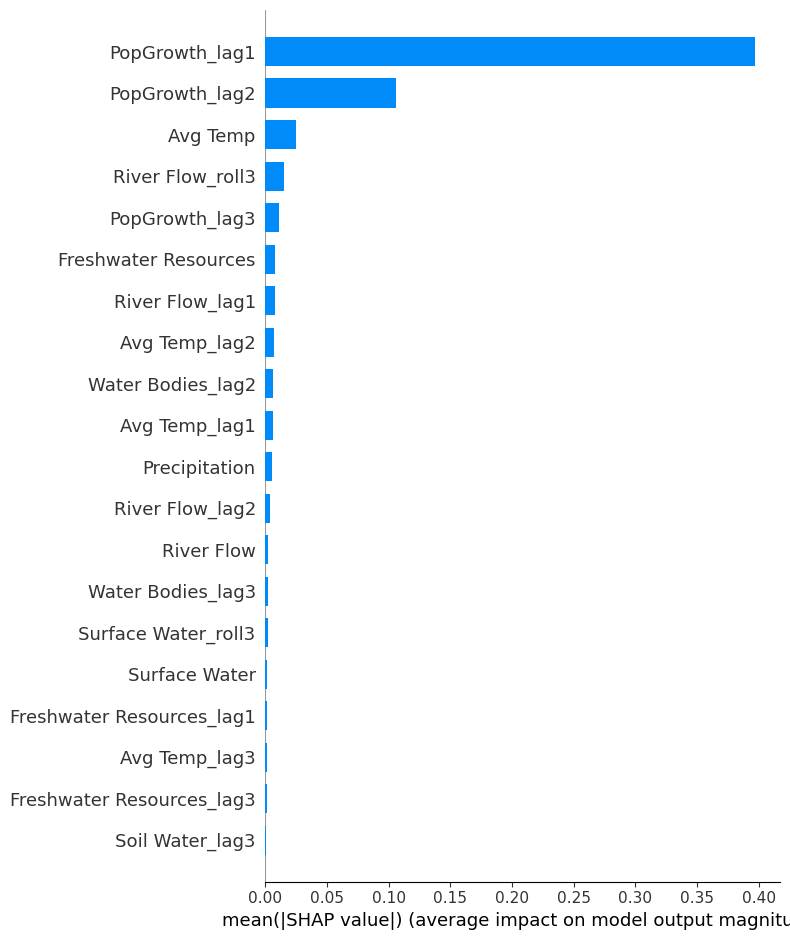

In [57]:
train_all = pg_clean[pg_clean["Year"] < 2024].dropna(
    subset=extended_features_nocountry + [target]
)

X_train_all = train_all[extended_features_nocountry]
y_train_all = train_all[target]

final_model = XGBRegressor(
    **best_params,
    objective="reg:squarederror",
    random_state=42
)

final_model.fit(X_train_all, y_train_all)

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_train_all)

shap.summary_plot(shap_values, X_train_all, plot_type="bar")


This confirms our suspicions. Considering the SHAP Plot from above before creating the lags, we can see that overall this is a country baseline problem as opposed to a hydrological one. Hydrological features act as geographic identifies.

Hence, we mostly have potential evidence that climate is correlated with economic development (at least in Africa), rather than hydrological variables being a direct driver of population growth. This provides us with an interesting direction heading forward and is a compelling conclusion.

## Final Test

Test size: 53
Final Test RMSE: 0.4550
Final Test R²:   0.7450
                             Country    Actual  Predicted     Error
8           Central African Republic  3.401398   1.730801  1.670597
45                       South Sudan  3.927924   2.533479  1.394445
11                          Djibouti  1.359217   0.399261  0.959956
49                           Tunisia  0.626519   1.579051  0.952532
31                         Mauritius -0.229950   0.705475  0.935425
9                               Chad  4.948530   4.228262  0.720268
41                        Seychelles  1.311361   0.720973  0.590388
26                             Libya  1.026299   1.593963  0.567664
19                             Ghana  1.875000   1.312242  0.562758
32                           Morocco  0.972828   1.524452  0.551624
46                             Sudan  0.808373   1.359018  0.550645
43                           Somalia  3.482155   2.990750  0.491405
0                            Algeria  1.398387   1.889

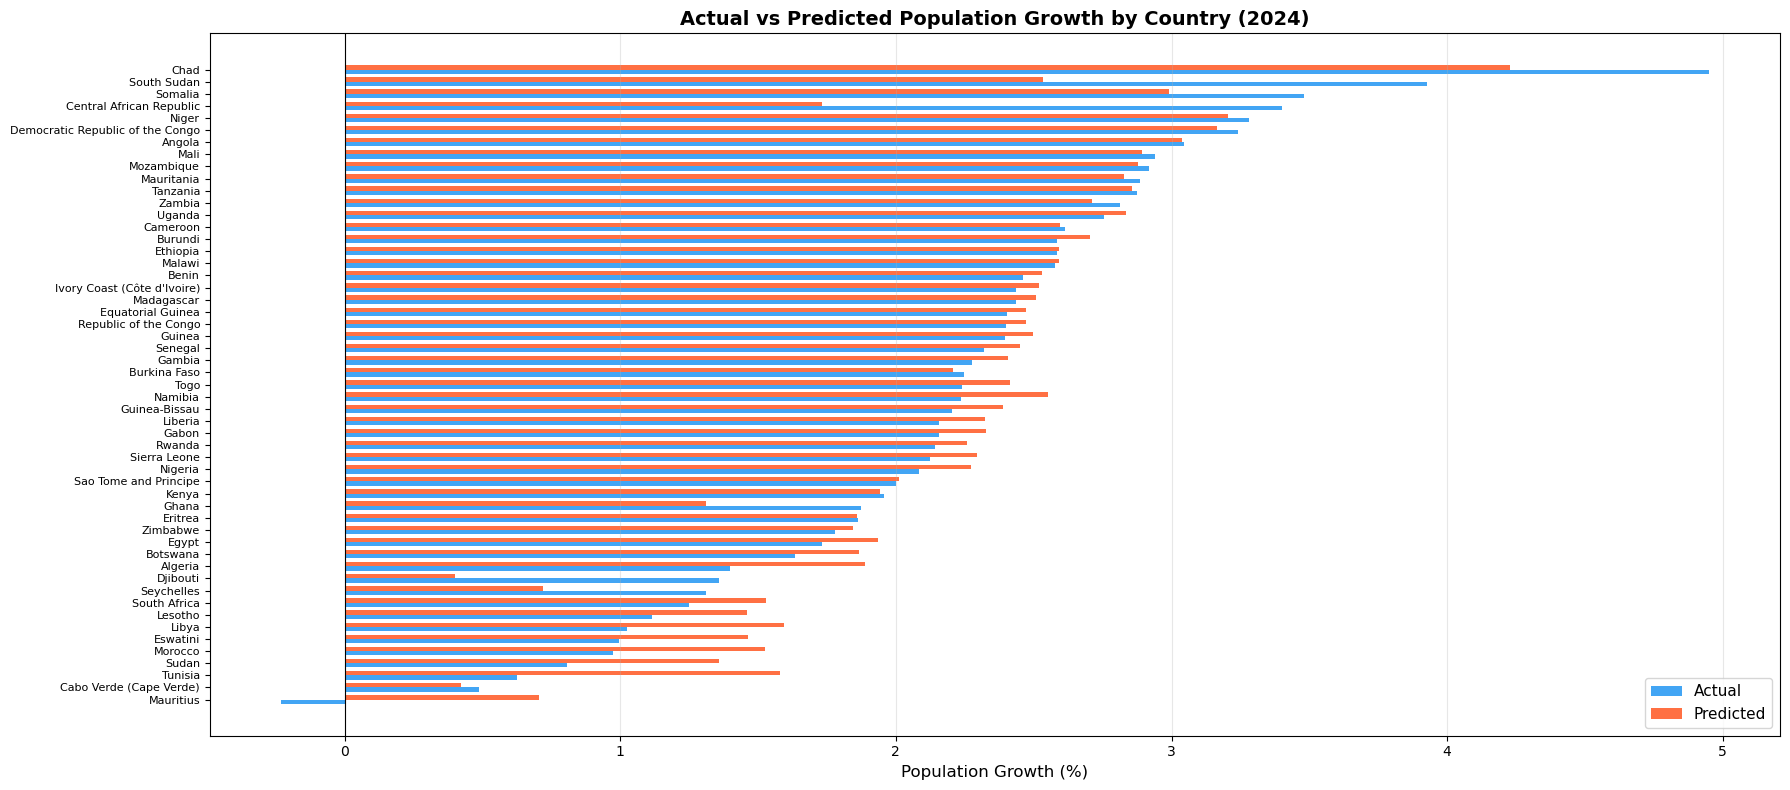

In [58]:
pg_full = df[(df["Year"] <= 2024) & (~df["Year"].isin([2020, 2021]))].copy()
pg_full = clean_numeric(pg_full, ws_numeric_cols)
pg_full = pg_full.sort_values(["Country", "Year"])
pg_full = pg_full.dropna(subset=[target])

for col in hydro_features:
    pg_full[f"{col}_lag1"] = pg_full.groupby("Country")[col].shift(1)
    pg_full[f"{col}_lag2"] = pg_full.groupby("Country")[col].shift(2)
    pg_full[f"{col}_lag3"] = pg_full.groupby("Country")[col].shift(3)

for col in hydro_features:
    pg_full[f"{col}_roll3"] = pg_full.groupby("Country")[col].transform(
        lambda x: x.shift(1).rolling(3).mean()
    )

pg_full["PopGrowth_lag1"] = pg_full.groupby("Country")[target].shift(1)
pg_full["PopGrowth_lag2"] = pg_full.groupby("Country")[target].shift(2)
pg_full["PopGrowth_lag3"] = pg_full.groupby("Country")[target].shift(3)

extended_features_nocountry = [
    f for f in extended_features_nocountry
    if "Freshwater" not in f
]

test_final = pg_full[pg_full["Year"] == 2024].copy()
train_final_imp = pg_full[pg_full["Year"] < 2024].dropna(subset=[target])
col_medians = train_final_imp[extended_features_nocountry].median()
test_final[extended_features_nocountry] = test_final[extended_features_nocountry].fillna(col_medians)
test_final = test_final.dropna(subset=[target])

print("Test size:", len(test_final))

train_final = pg_full[pg_full["Year"] < 2024].dropna(subset=extended_features_nocountry + [target])

X_train_final = train_final[extended_features_nocountry]
y_train_final = train_final[target]

X_test_final = test_final[extended_features_nocountry]
y_test_final = test_final[target]

final_model = XGBRegressor(
    **best_params,
    objective="reg:squarederror",
    random_state=42
)

final_model.fit(X_train_final, y_train_final)
preds_final = final_model.predict(X_test_final)

rmse_final = mean_squared_error(y_test_final, preds_final) ** 0.5
r2_final = r2_score(y_test_final, preds_final)

print(f"Final Test RMSE: {rmse_final:.4f}")
print(f"Final Test R²:   {r2_final:.4f}")

final_results = pd.DataFrame({
    "Country": test_final["Country"].values,
    "Actual": y_test_final.values,
    "Predicted": preds_final,
    "Error": abs(y_test_final.values - preds_final)
}).sort_values("Error", ascending=False)

print(final_results)

final_results_sorted = final_results.sort_values("Actual", ascending=True)

x = np.arange(len(final_results_sorted))
width = 0.35

fig, ax = plt.subplots(figsize=(18, 8))

ax.barh(x - width/2, final_results_sorted["Actual"], width,
        label="Actual", color="#2196F3", alpha=0.85)
ax.barh(x + width/2, final_results_sorted["Predicted"], width,
        label="Predicted", color="#FF5722", alpha=0.85)

ax.set_yticks(x)
ax.set_yticklabels(final_results_sorted["Country"], fontsize=8)
ax.set_xlabel("Population Growth (%)", fontsize=12)
ax.set_title("Actual vs Predicted Population Growth by Country (2024)",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.axvline(x=0, color="black", linewidth=0.8)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

Dropping Poor Performing Countries - combined team effort



Test size: 46
Final Test RMSE: 0.3834
Final Test R²:   0.7706
                             Country    Actual  Predicted     Error
8                               Chad  4.948530   3.527829  1.420701
6            Cabo Verde (Cape Verde)  0.486246   1.609467  1.123221
39                             Sudan  0.808373   1.765987  0.957614
42                           Tunisia  0.626519   1.518864  0.892345
28                           Morocco  0.972828   1.519008  0.546180
13                          Eswatini  0.995913   1.541747  0.545834
23                             Libya  1.026299   1.551970  0.525671
0                            Algeria  1.398387   1.790331  0.391944
21                           Lesotho  1.116449   1.491413  0.374964
30                           Namibia  2.237152   2.570356  0.333204
38                      South Africa  1.249514   1.506364  0.256850
32                           Nigeria  2.082978   2.286535  0.203557
10                             Egypt  1.733242   1.926

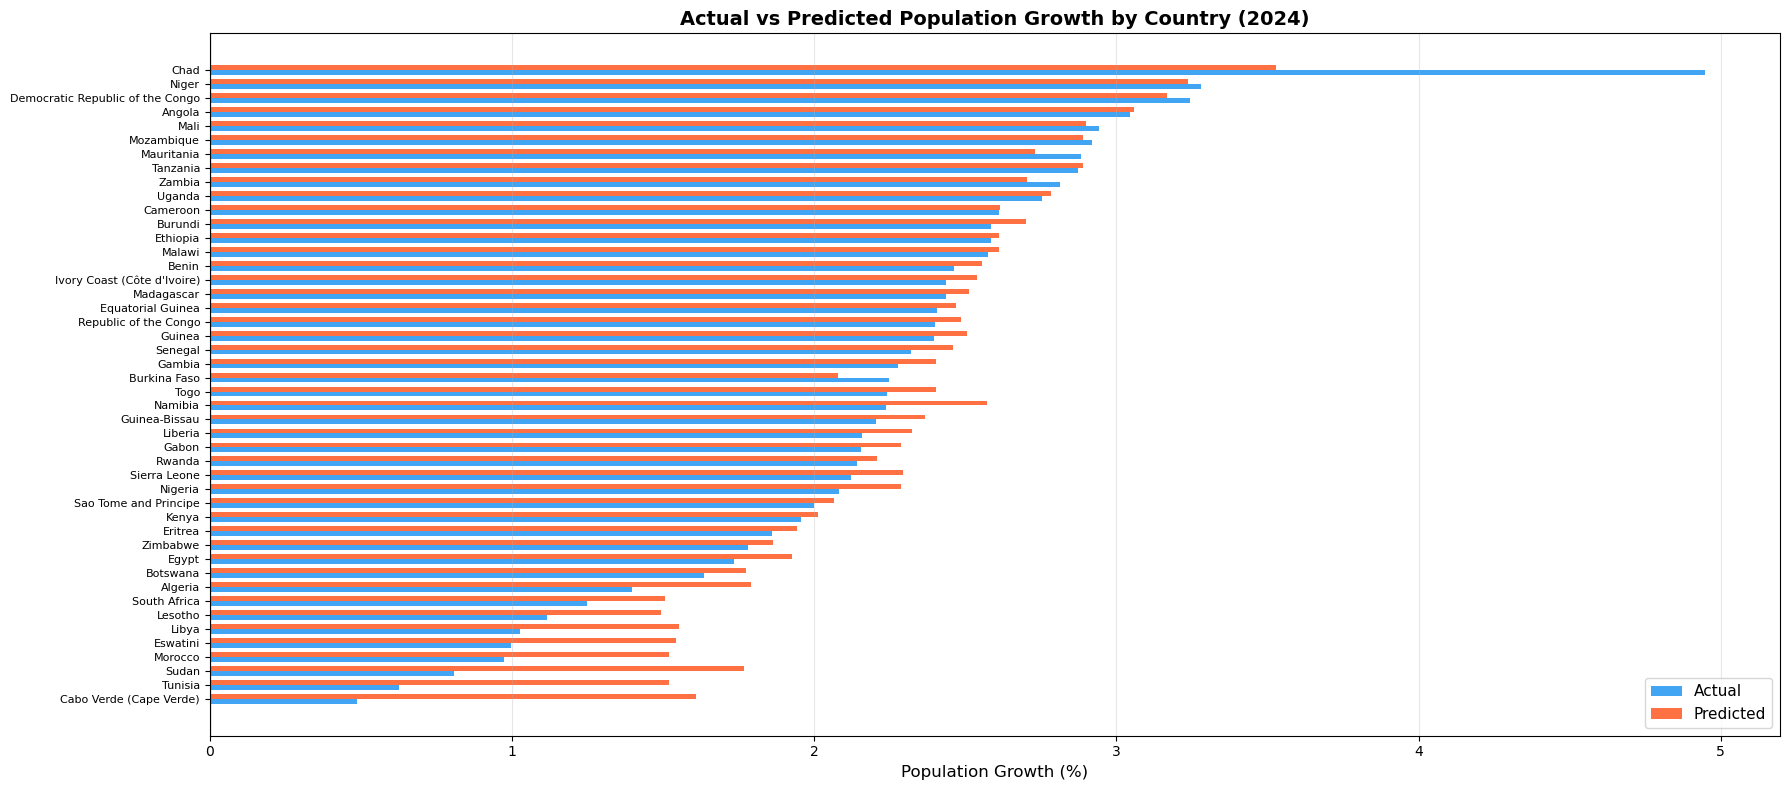

In [59]:
# Countries to exclude
drop_countries = [
    "Somalia",
    "South Sudan",
    "Central African Republic",
    "Seychelles",
    "Mauritius",
    "Ghana",
    "Djibouti"
]

# Build pg_full from df including 2024, excluding COVID years AND drop countries
pg_full = df[
    (df["Year"] <= 2024) &
    (~df["Year"].isin([2020, 2021])) &
    (~df["Country"].isin(drop_countries))
].copy()

pg_full = clean_numeric(pg_full, ws_numeric_cols)
pg_full = pg_full.sort_values(["Country", "Year"])
pg_full = pg_full.dropna(subset=[target])

# Build lag features
for col in hydro_features:
    pg_full[f"{col}_lag1"] = pg_full.groupby("Country")[col].shift(1)
    pg_full[f"{col}_lag2"] = pg_full.groupby("Country")[col].shift(2)
    pg_full[f"{col}_lag3"] = pg_full.groupby("Country")[col].shift(3)

# Rolling means
for col in hydro_features:
    pg_full[f"{col}_roll3"] = pg_full.groupby("Country")[col].transform(
        lambda x: x.shift(1).rolling(3).mean()
    )

# Lagged Population Growth
pg_full["PopGrowth_lag1"] = pg_full.groupby("Country")[target].shift(1)
pg_full["PopGrowth_lag2"] = pg_full.groupby("Country")[target].shift(2)
pg_full["PopGrowth_lag3"] = pg_full.groupby("Country")[target].shift(3)

# Remove Freshwater Resources features
extended_features_nocountry = [
    f for f in extended_features_nocountry
    if "Freshwater" not in f
]

# -----------------------------
# Build final 2024 test set
# -----------------------------
test_final = pg_full[pg_full["Year"] == 2024].copy()

train_final_imp = pg_full[pg_full["Year"] < 2024].dropna(subset=[target])
col_medians = train_final_imp[extended_features_nocountry].median()

test_final[extended_features_nocountry] = (
    test_final[extended_features_nocountry].fillna(col_medians)
)

test_final = test_final.dropna(subset=[target])

print("Test size:", len(test_final))

# -----------------------------
# Build training set
# -----------------------------
train_final = pg_full[pg_full["Year"] < 2024].dropna(
    subset=extended_features_nocountry + [target]
)

X_train_final = train_final[extended_features_nocountry]
y_train_final = train_final[target]

X_test_final = test_final[extended_features_nocountry]
y_test_final = test_final[target]

# -----------------------------
# Fit and evaluate final model
# -----------------------------
final_model = XGBRegressor(
    **best_params,
    objective="reg:squarederror",
    random_state=42
)

final_model.fit(X_train_final, y_train_final)
preds_final = final_model.predict(X_test_final)

rmse_final = mean_squared_error(y_test_final, preds_final) ** 0.5
r2_final = r2_score(y_test_final, preds_final)

print(f"Final Test RMSE: {rmse_final:.4f}")
print(f"Final Test R²:   {r2_final:.4f}")

# -----------------------------
# Results table
# -----------------------------
final_results = pd.DataFrame({
    "Country": test_final["Country"].values,
    "Actual": y_test_final.values,
    "Predicted": preds_final,
    "Error": abs(y_test_final.values - preds_final)
}).sort_values("Error", ascending=False)

print(final_results)

# -----------------------------
# Plot Actual vs Predicted
# -----------------------------
final_results_sorted = final_results.sort_values("Actual", ascending=True)

x = np.arange(len(final_results_sorted))
width = 0.35

fig, ax = plt.subplots(figsize=(18, 8))

ax.barh(x - width/2, final_results_sorted["Actual"], width,
        label="Actual", color="#2196F3", alpha=0.85)
ax.barh(x + width/2, final_results_sorted["Predicted"], width,
        label="Predicted", color="#FF5722", alpha=0.85)

ax.set_yticks(x)
ax.set_yticklabels(final_results_sorted["Country"], fontsize=8)
ax.set_xlabel("Population Growth (%)", fontsize=12)
ax.set_title("Actual vs Predicted Population Growth by Country (2024)",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.axvline(x=0, color="black", linewidth=0.8)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()


## Binning Countries into Regions

In [60]:
import pandas as pd
import numpy as np

# ── 1. COMPUTE MEAN PRECIPITATION PER COUNTRY ──
country_precip = pg.groupby("Country")["Precipitation"].mean().sort_values()

print("Mean Precipitation per Country:")
print(country_precip.round(2))

# ── 2. BIN INTO 3 GROUPS USING QUANTILES ──
# 33rd percentile = Dry, 33-66th = Mid, 66th+ = Wet
dry_threshold = country_precip.quantile(0.33)
wet_threshold = country_precip.quantile(0.66)

print(f"\nDry threshold  (33rd percentile): {dry_threshold:.2f}")
print(f"Wet threshold  (66th percentile): {wet_threshold:.2f}")

# ── 3. ASSIGN REGION BASED ON DATA ──
def assign_region(country):
    if country not in country_precip.index:
        return "Unknown"
    precip = country_precip[country]
    if precip <= dry_threshold:
        return "Dry"
    elif precip <= wet_threshold:
        return "Mid"
    else:
        return "Wet"

pg["Precip_Region"] = pg["Country"].apply(assign_region)

# ── 4. CHECK RESULTS ──
region_summary = (pg[["Country", "Precipitation", "Precip_Region"]]
                  .groupby(["Country", "Precip_Region"])["Precipitation"]
                  .mean()
                  .reset_index()
                  .sort_values(["Precip_Region", "Precipitation"]))

print("\nRegion assignments:")
for region in ["Dry", "Mid", "Wet"]:
    countries = region_summary[region_summary["Precip_Region"] == region]
    print(f"\n{region} ({len(countries)} countries, "
          f"precip range: {countries['Precipitation'].min():.1f}–{countries['Precipitation'].max():.1f}):")
    print(countries[["Country", "Precipitation"]].to_string(index=False))

# ── 5. CHECK UNKNOWNS ──
unknowns = pg[pg["Precip_Region"] == "Unknown"]["Country"].unique()
if len(unknowns) > 0:
    print(f"\n⚠️ Unassigned countries: {unknowns}")
else:
    print("\n✅ All countries assigned!")

Mean Precipitation per Country:
Country
Egypt             14.39
Libya             25.96
Algeria           77.00
Sudan            175.91
Mali             253.96
Morocco          264.65
Chad             267.41
Namibia          302.04
South Africa     487.22
Kenya            576.78
Senegal          592.39
Burkina Faso     680.59
Zimbabwe         695.48
Ethiopia         737.90
South Sudan      777.25
Mozambique       941.30
Benin            987.23
Zambia          1025.65
Angola          1026.18
Niger           1081.70
Togo            1109.65
Malawi          1110.83
Rwanda          1116.96
Ghana           1125.61
Uganda          1141.43
Madagascar      1393.65
Cameroon        1510.14
Guinea          1711.87
Liberia         2629.17
Sierra Leone    2717.04
Name: Precipitation, dtype: float64

Dry threshold  (33rd percentile): 585.68
Wet threshold  (66th percentile): 1085.61

Region assignments:

Dry (10 countries, precip range: 14.4–576.8):
     Country  Precipitation
       Egypt      14.391

Wet   | Countries: 10 | Years tested: 17 | Mean R²: -1.5045 | Std R²: 5.1510 | Mean RMSE: 0.3574 | Std RMSE: 0.2459
Mid   | Countries: 10 | Years tested: 17 | Mean R²: 0.6630 | Std R²: 0.3398 | Mean RMSE: 0.3972 | Std RMSE: 0.3297
Dry   | Countries: 10 | Years tested: 17 | Mean R²: 0.6987 | Std R²: 0.2777 | Mean RMSE: 0.4504 | Std RMSE: 0.3912


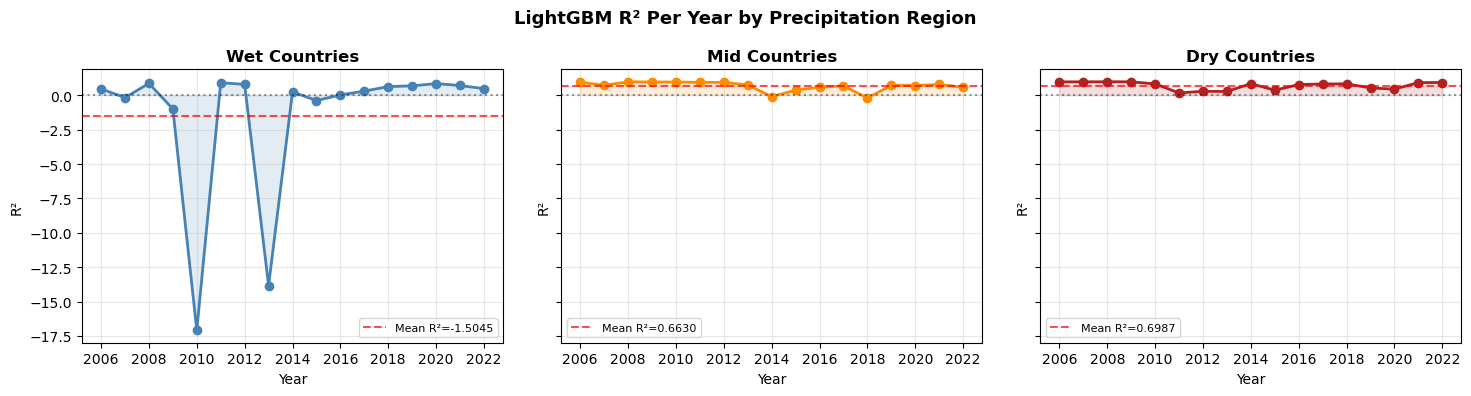

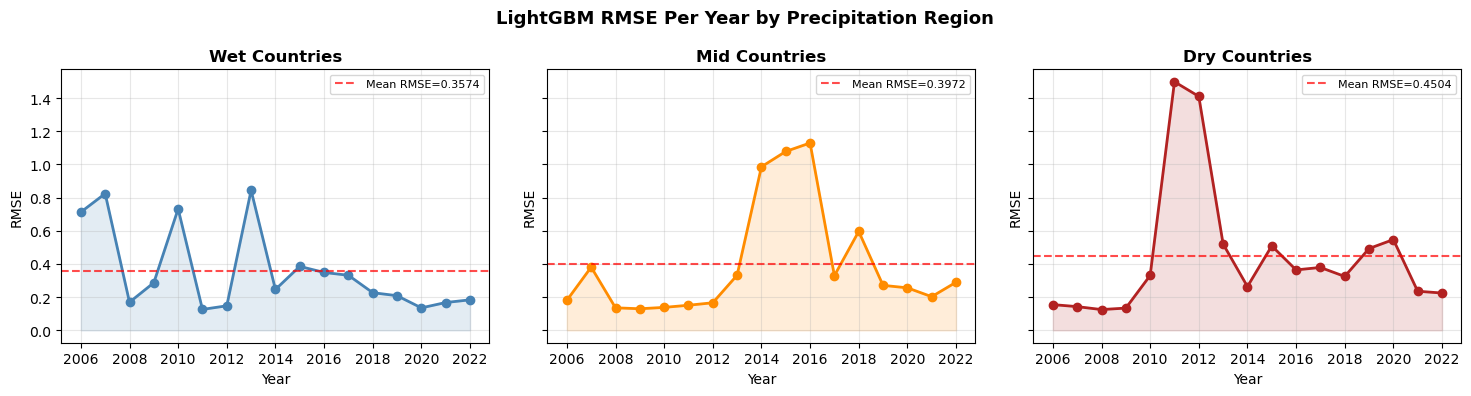

C:\Users\sidne\AppData\Local\Temp\ipykernel_14784\246044123.py:121: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


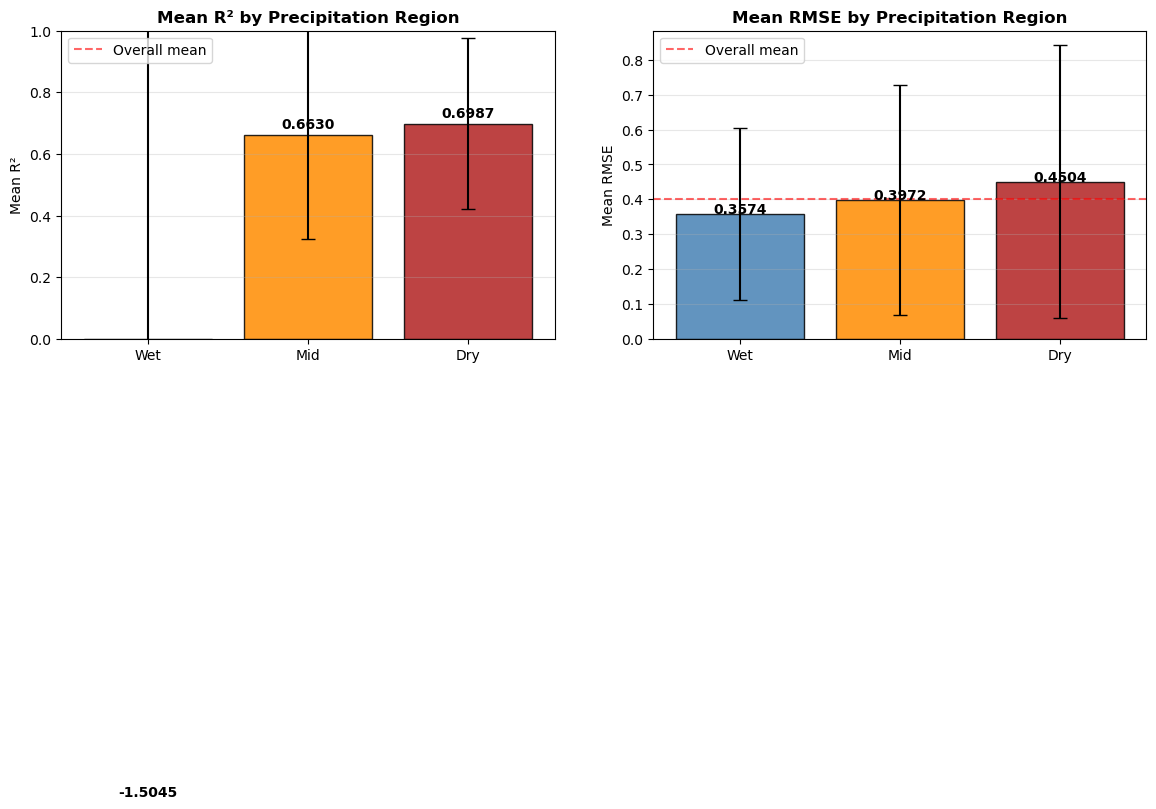

In [61]:
import lightgbm as lgb
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

regions = ["Wet", "Mid", "Dry"]
region_scores = {}
region_rmse   = {}

for region in regions:
    pg_region = pg[pg["Precip_Region"] == region].copy()
    years_region = sorted(pg_region["Year"].unique())

    scores = []
    rmses  = []

    for test_year in years_region:
        if test_year <= 2005:
            continue

        train = pg_region[pg_region["Year"] < test_year].dropna(subset=hydro_features)
        test  = pg_region[pg_region["Year"] == test_year].dropna(subset=hydro_features)

        if len(test) == 0 or len(train) < 10:
            continue

        model = lgb.LGBMRegressor(
            n_estimators=1000, learning_rate=0.01, max_depth=4,
            num_leaves=15, subsample=0.8, colsample_bytree=0.7,
            min_child_samples=5, reg_alpha=0.1, reg_lambda=1.0,
            random_state=42, verbose=-1
        )
        model.fit(train[hydro_features], train[target])
        preds = model.predict(test[hydro_features])

        scores.append(r2_score(test[target], preds))
        rmses.append(mean_squared_error(test[target], preds) ** 0.5)

    region_scores[region] = scores
    region_rmse[region]   = rmses

    print(f"{region:5s} | Countries: {pg_region['Country'].nunique():2d} | "
          f"Years tested: {len(scores):2d} | "
          f"Mean R²: {np.mean(scores):.4f} | Std R²: {np.std(scores):.4f} | "
          f"Mean RMSE: {np.mean(rmses):.4f} | Std RMSE: {np.std(rmses):.4f}")

# ── R² PER YEAR PLOT ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
colors = {"Wet": "steelblue", "Mid": "darkorange", "Dry": "firebrick"}

for ax, region in zip(axes, regions):
    scores = region_scores[region]
    years_plot = [y for y in sorted(pg["Year"].unique()) if y > 2005][:len(scores)]
    ax.plot(years_plot, scores, marker="o", color=colors[region], linewidth=2)
    ax.fill_between(years_plot, scores, alpha=0.15, color=colors[region])
    ax.axhline(y=np.mean(scores), color="red", linestyle="--", alpha=0.7,
               label=f"Mean R²={np.mean(scores):.4f}")
    ax.axhline(y=0, color="black", linestyle=":", alpha=0.4)
    ax.set_title(f"{region} Countries", fontsize=12, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("R²")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("LightGBM R² Per Year by Precipitation Region", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── RMSE PER YEAR PLOT ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, region in zip(axes, regions):
    rmses = region_rmse[region]
    years_plot = [y for y in sorted(pg["Year"].unique()) if y > 2005][:len(rmses)]
    ax.plot(years_plot, rmses, marker="o", color=colors[region], linewidth=2)
    ax.fill_between(years_plot, rmses, alpha=0.15, color=colors[region])
    ax.axhline(y=np.mean(rmses), color="red", linestyle="--", alpha=0.7,
               label=f"Mean RMSE={np.mean(rmses):.4f}")
    ax.set_title(f"{region} Countries", fontsize=12, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("RMSE")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("LightGBM RMSE Per Year by Precipitation Region", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── SUMMARY BAR CHARTS — R² AND RMSE SIDE BY SIDE ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# R² bar
means_r2 = [np.mean(region_scores[r]) for r in regions]
stds_r2  = [np.std(region_scores[r])  for r in regions]
bars = axes[0].bar(regions, means_r2, color=[colors[r] for r in regions],
                   edgecolor="black", alpha=0.85, yerr=stds_r2, capsize=5)
axes[0].axhline(y=np.mean(means_r2), color="red", linestyle="--", alpha=0.6, label="Overall mean")
axes[0].set_title("Mean R² by Precipitation Region", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Mean R²")
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="y")
for bar, mean in zip(bars, means_r2):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{mean:.4f}", ha="center", fontsize=10, fontweight="bold")

# RMSE bar
means_rmse = [np.mean(region_rmse[r]) for r in regions]
stds_rmse  = [np.std(region_rmse[r])  for r in regions]
bars = axes[1].bar(regions, means_rmse, color=[colors[r] for r in regions],
                   edgecolor="black", alpha=0.85, yerr=stds_rmse, capsize=5)
axes[1].axhline(y=np.mean(means_rmse), color="red", linestyle="--", alpha=0.6, label="Overall mean")
axes[1].set_title("Mean RMSE by Precipitation Region", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Mean RMSE")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")
for bar, mean in zip(bars, means_rmse):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f"{mean:.4f}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()


🔍 Grid searching for Wet region (243 combinations)...
✅ Best params for Wet: {'learning_rate': 0.005, 'max_depth': 6, 'min_child_samples': 20, 'n_estimators': 500, 'num_leaves': 8} | Tuning R²: -0.4559
Wet   | Countries: 10 | Years tested: 17 | Mean R²: -0.2373 | Std R²: 0.7877 | Mean RMSE: 0.3948 | Std RMSE: 0.2028

🔍 Grid searching for Mid region (243 combinations)...
✅ Best params for Mid: {'learning_rate': 0.01, 'max_depth': 4, 'min_child_samples': 5, 'n_estimators': 2000, 'num_leaves': 15} | Tuning R²: 0.7383
Mid   | Countries: 10 | Years tested: 17 | Mean R²: 0.6663 | Std R²: 0.3550 | Mean RMSE: 0.3878 | Std RMSE: 0.3142

🔍 Grid searching for Dry region (243 combinations)...
✅ Best params for Dry: {'learning_rate': 0.01, 'max_depth': 6, 'min_child_samples': 10, 'n_estimators': 2000, 'num_leaves': 8} | Tuning R²: 0.7366
Dry   | Countries: 10 | Years tested: 17 | Mean R²: 0.7325 | Std R²: 0.2503 | Mean RMSE: 0.4165 | Std RMSE: 0.3373


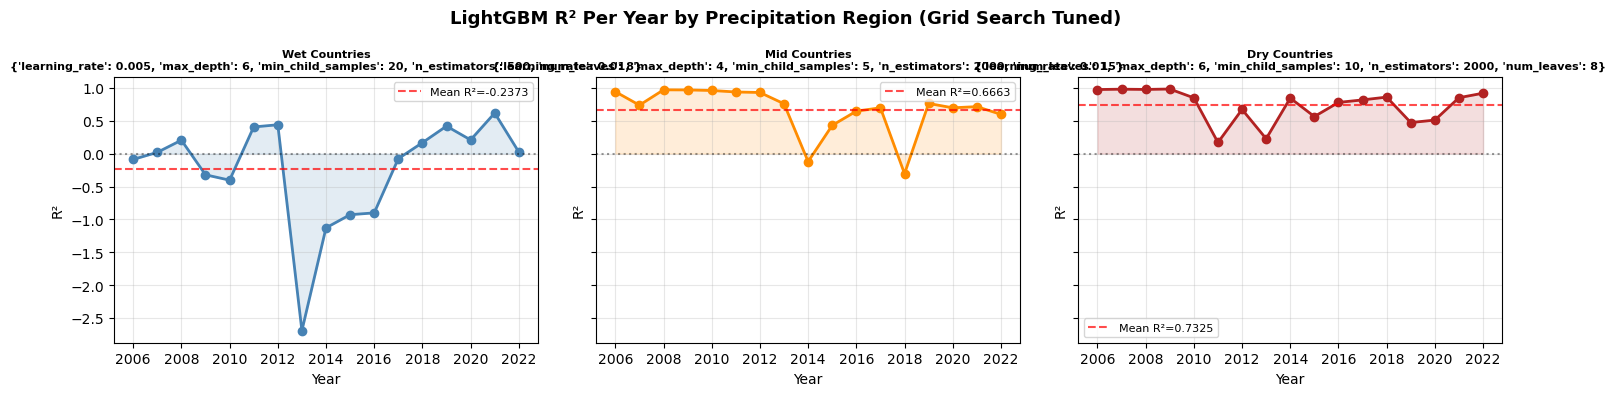

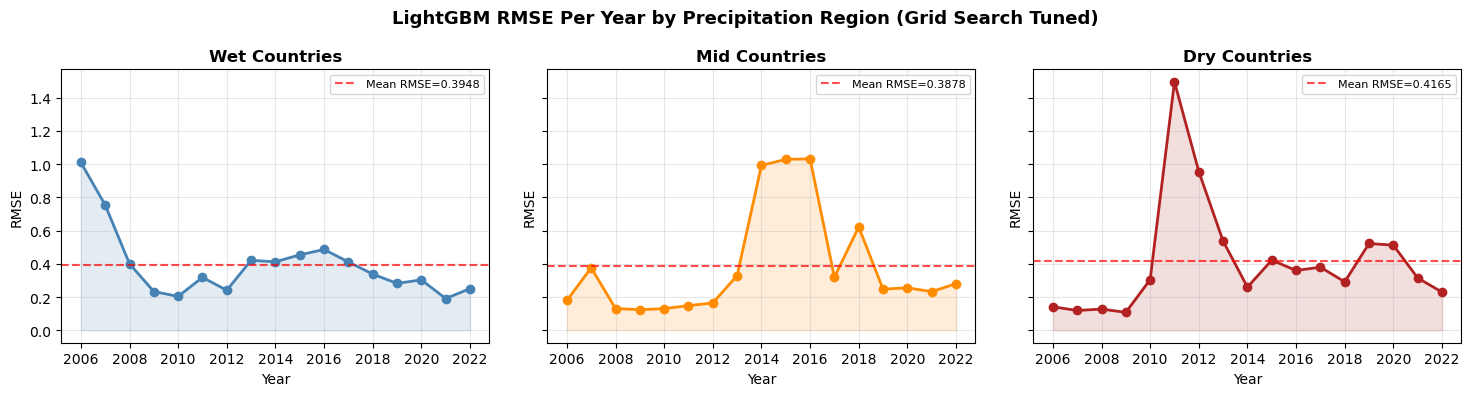

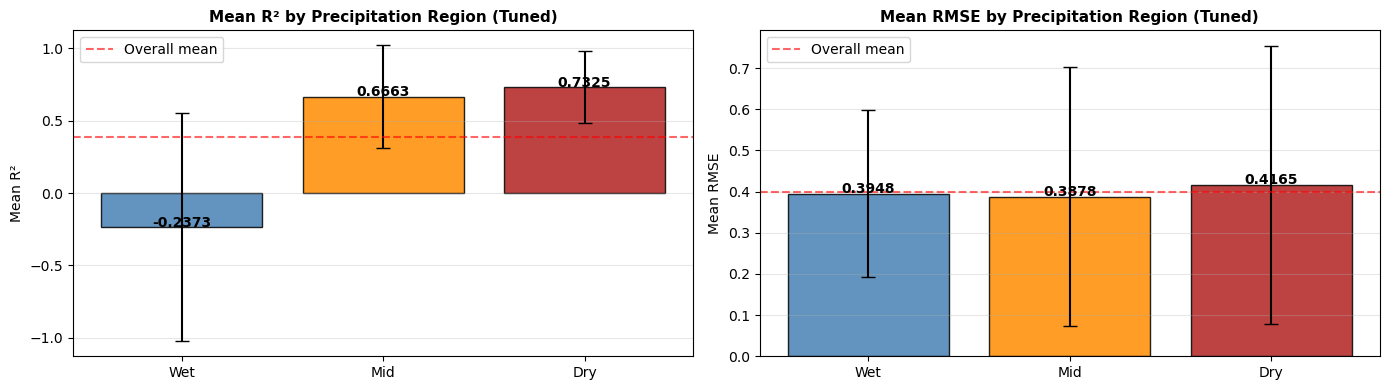

In [68]:
import lightgbm as lgb
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import ParameterGrid
import numpy as np
import matplotlib.pyplot as plt

# ── GRID SEARCH PARAMS ──
param_grid = {
    "n_estimators":     [500, 1000, 2000],
    "learning_rate":    [0.005, 0.01, 0.05],
    "max_depth":        [3, 4, 6],
    "num_leaves":       [8, 15, 31],
    "min_child_samples":[5, 10, 20],
}

regions = ["Wet", "Mid", "Dry"]
region_scores    = {}
region_rmse      = {}
region_bestparams = {}

for region in regions:
    pg_region    = pg[pg["Precip_Region"] == region].copy()
    years_region = sorted(pg_region["Year"].unique())

    # ── GRID SEARCH — use first 70% of years for tuning ──
    tune_years = [y for y in years_region if y > 2005]
    split_idx  = int(len(tune_years) * 0.7)
    tune_years_train = tune_years[:split_idx]
    tune_years_test  = tune_years[split_idx:]

    best_r2     = -999
    best_params = None

    print(f"\n🔍 Grid searching for {region} region ({len(list(ParameterGrid(param_grid)))} combinations)...")

    for params in ParameterGrid(param_grid):
        fold_scores = []

        for test_year in tune_years_train:
            train = pg_region[pg_region["Year"] < test_year].dropna(subset=hydro_features)
            test  = pg_region[pg_region["Year"] == test_year].dropna(subset=hydro_features)

            if len(test) == 0 or len(train) < 10:
                continue

            model = lgb.LGBMRegressor(
                **params,
                reg_alpha=0.1, reg_lambda=1.0,
                subsample=0.8, colsample_bytree=0.7,
                random_state=42, verbose=-1
            )
            model.fit(train[hydro_features], train[target])
            preds = model.predict(test[hydro_features])
            fold_scores.append(r2_score(test[target], preds))

        if len(fold_scores) == 0:
            continue

        mean_r2 = np.mean(fold_scores)
        if mean_r2 > best_r2:
            best_r2     = mean_r2
            best_params = params

    region_bestparams[region] = best_params
    print(f"✅ Best params for {region}: {best_params} | Tuning R²: {best_r2:.4f}")

    # ── EVALUATE ON HELD-OUT YEARS WITH BEST PARAMS ──
    scores = []
    rmses  = []

    for test_year in years_region:
        if test_year <= 2005:
            continue

        train = pg_region[pg_region["Year"] < test_year].dropna(subset=hydro_features)
        test  = pg_region[pg_region["Year"] == test_year].dropna(subset=hydro_features)

        if len(test) == 0 or len(train) < 10:
            continue

        model = lgb.LGBMRegressor(
            **best_params,
            reg_alpha=0.1, reg_lambda=1.0,
            subsample=0.8, colsample_bytree=0.7,
            random_state=42, verbose=-1
        )
        model.fit(train[hydro_features], train[target])
        preds = model.predict(test[hydro_features])

        scores.append(r2_score(test[target], preds))
        rmses.append(mean_squared_error(test[target], preds) ** 0.5)

    region_scores[region] = scores
    region_rmse[region]   = rmses

    print(f"{region:5s} | Countries: {pg_region['Country'].nunique():2d} | "
          f"Years tested: {len(scores):2d} | "
          f"Mean R²: {np.mean(scores):.4f} | Std R²: {np.std(scores):.4f} | "
          f"Mean RMSE: {np.mean(rmses):.4f} | Std RMSE: {np.std(rmses):.4f}")

# ── R² PER YEAR PLOT ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
colors = {"Wet": "steelblue", "Mid": "darkorange", "Dry": "firebrick"}

for ax, region in zip(axes, regions):
    scores     = region_scores[region]
    years_plot = [y for y in sorted(pg["Year"].unique()) if y > 2005][:len(scores)]
    ax.plot(years_plot, scores, marker="o", color=colors[region], linewidth=2)
    ax.fill_between(years_plot, scores, alpha=0.15, color=colors[region])
    ax.axhline(y=np.mean(scores), color="red", linestyle="--", alpha=0.7,
               label=f"Mean R²={np.mean(scores):.4f}")
    ax.axhline(y=0, color="black", linestyle=":", alpha=0.4)
    ax.set_title(f"{region} Countries\n{region_bestparams[region]}", fontsize=8, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("R²")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("LightGBM R² Per Year by Precipitation Region (Grid Search Tuned)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── RMSE PER YEAR PLOT ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, region in zip(axes, regions):
    rmses      = region_rmse[region]
    years_plot = [y for y in sorted(pg["Year"].unique()) if y > 2005][:len(rmses)]
    ax.plot(years_plot, rmses, marker="o", color=colors[region], linewidth=2)
    ax.fill_between(years_plot, rmses, alpha=0.15, color=colors[region])
    ax.axhline(y=np.mean(rmses), color="red", linestyle="--", alpha=0.7,
               label=f"Mean RMSE={np.mean(rmses):.4f}")
    ax.set_title(f"{region} Countries", fontsize=12, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("RMSE")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("LightGBM RMSE Per Year by Precipitation Region (Grid Search Tuned)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── SUMMARY BAR CHARTS ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

means_r2   = [np.mean(region_scores[r]) for r in regions]
stds_r2    = [np.std(region_scores[r])  for r in regions]
means_rmse = [np.mean(region_rmse[r])   for r in regions]
stds_rmse  = [np.std(region_rmse[r])    for r in regions]

for ax, means, stds, ylabel, title in zip(
    axes,
    [means_r2, means_rmse],
    [stds_r2,  stds_rmse],
    ["Mean R²", "Mean RMSE"],
    ["Mean R² by Precipitation Region (Tuned)", "Mean RMSE by Precipitation Region (Tuned)"]
):
    bars = ax.bar(regions, means, color=[colors[r] for r in regions],
                  edgecolor="black", alpha=0.85, yerr=stds, capsize=5)
    ax.axhline(y=np.mean(means), color="red", linestyle="--", alpha=0.6, label="Overall mean")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3, axis="y")
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f"{mean:.4f}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()


🔍 Grid searching for Wet region (243 combinations)...
✅ Best params for Wet: {'colsample_bytree': 0.6, 'learning_rate': 0.005, 'max_depth': 3, 'min_child_weight': 10, 'n_estimators': 500} | Tuning R²: -0.4992
Wet   | Countries: 10 | Years tested: 17 | Mean R²: -0.2603 | Std R²: 1.1407 | Mean RMSE: 0.3759 | Std RMSE: 0.2064

🔍 Grid searching for Mid region (243 combinations)...
✅ Best params for Mid: {'colsample_bytree': 0.6, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 10, 'n_estimators': 2000} | Tuning R²: 0.7223
Mid   | Countries: 10 | Years tested: 17 | Mean R²: 0.7011 | Std R²: 0.2823 | Mean RMSE: 0.3812 | Std RMSE: 0.3046

🔍 Grid searching for Dry region (243 combinations)...
✅ Best params for Dry: {'colsample_bytree': 0.8, 'learning_rate': 0.005, 'max_depth': 4, 'min_child_weight': 5, 'n_estimators': 500} | Tuning R²: 0.6814
Dry   | Countries: 10 | Years tested: 17 | Mean R²: 0.7296 | Std R²: 0.2534 | Mean RMSE: 0.4466 | Std RMSE: 0.4065


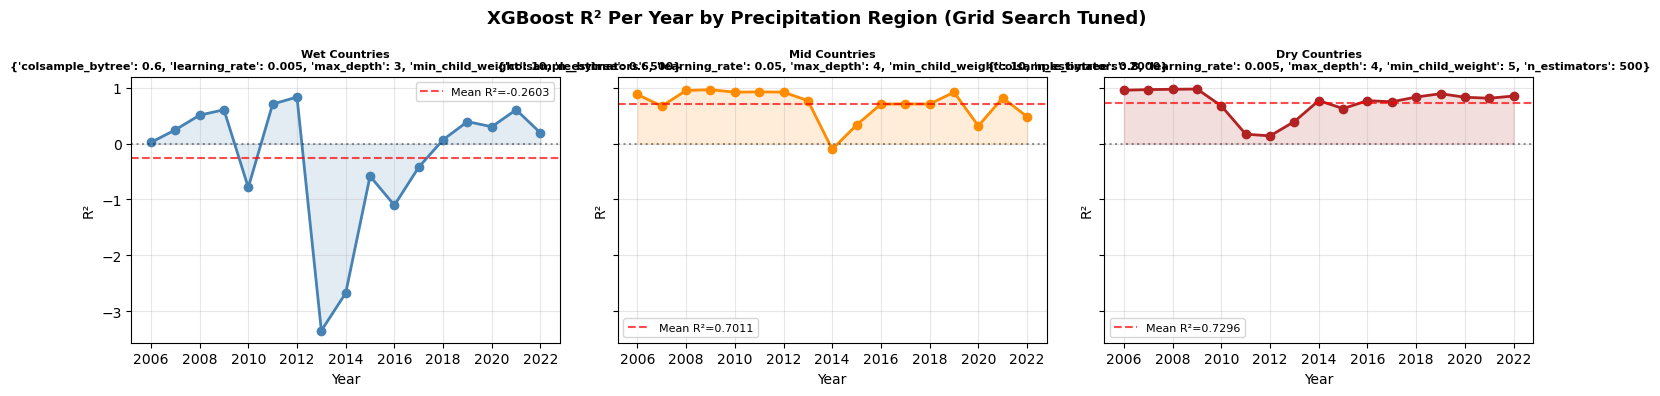

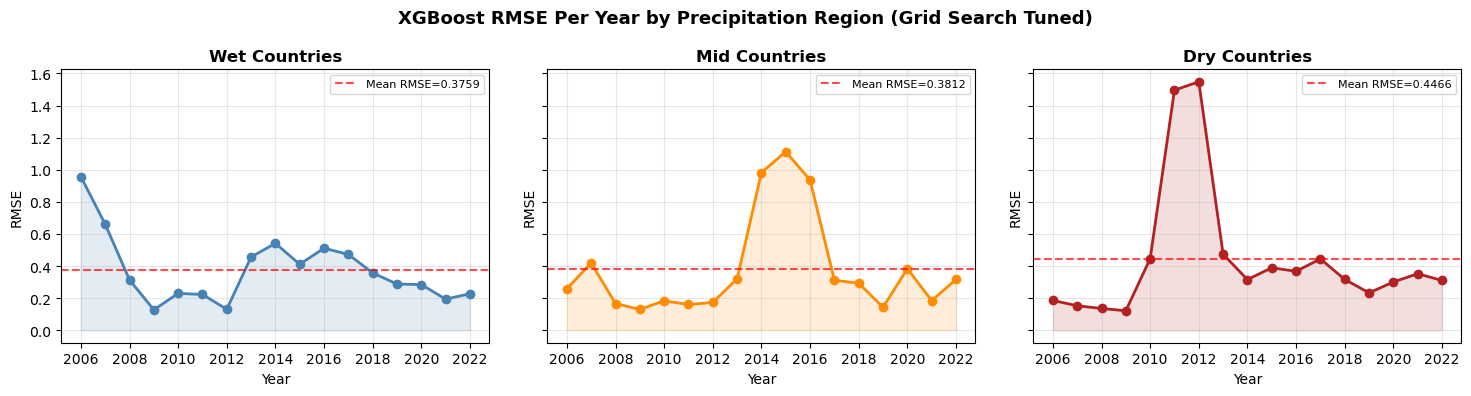

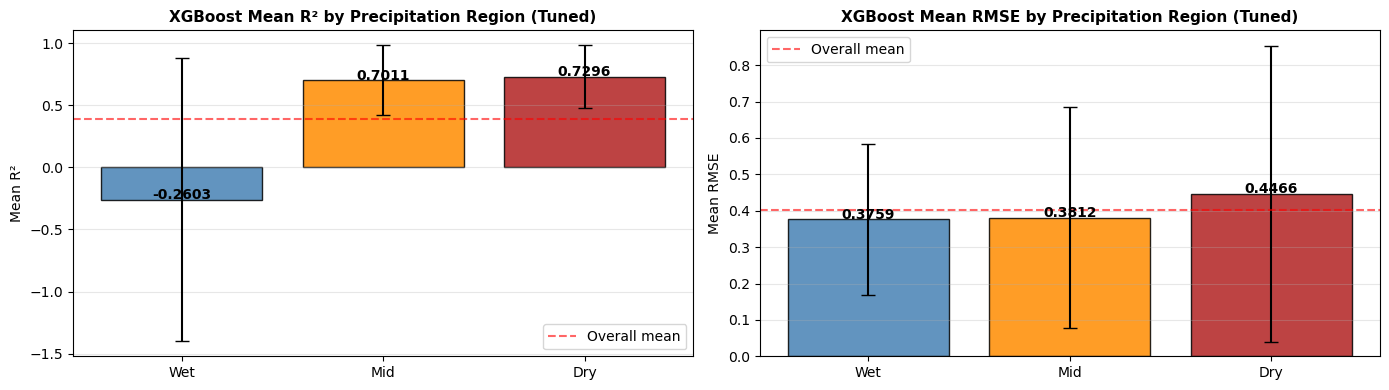

In [65]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import ParameterGrid
import numpy as np
import matplotlib.pyplot as plt

# ── GRID SEARCH PARAMS ──
param_grid = {
    "n_estimators":    [500, 1000, 2000],
    "learning_rate":   [0.005, 0.01, 0.05],
    "max_depth":       [3, 4, 6],
    "min_child_weight":[1, 5, 10],
    "colsample_bytree":[0.6, 0.7, 0.8],
}

regions = ["Wet", "Mid", "Dry"]
region_scores     = {}
region_rmse       = {}
region_bestparams = {}

for region in regions:
    pg_region    = pg[pg["Precip_Region"] == region].copy()
    years_region = sorted(pg_region["Year"].unique())

    # ── GRID SEARCH — use first 70% of years for tuning ──
    tune_years       = [y for y in years_region if y > 2005]
    split_idx        = int(len(tune_years) * 0.7)
    tune_years_train = tune_years[:split_idx]

    best_r2     = -999
    best_params = None

    print(f"\n🔍 Grid searching for {region} region ({len(list(ParameterGrid(param_grid)))} combinations)...")

    for params in ParameterGrid(param_grid):
        fold_scores = []

        for test_year in tune_years_train:
            train = pg_region[pg_region["Year"] < test_year].dropna(subset=hydro_features)
            test  = pg_region[pg_region["Year"] == test_year].dropna(subset=hydro_features)

            if len(test) == 0 or len(train) < 10:
                continue

            model = XGBRegressor(
                **params,
                subsample=0.8,
                reg_alpha=0.1, reg_lambda=1.0,
                objective="reg:squarederror",
                random_state=42, verbosity=0
            )
            model.fit(train[hydro_features], train[target])
            preds = model.predict(test[hydro_features])
            fold_scores.append(r2_score(test[target], preds))

        if len(fold_scores) == 0:
            continue

        mean_r2 = np.mean(fold_scores)
        if mean_r2 > best_r2:
            best_r2     = mean_r2
            best_params = params

    region_bestparams[region] = best_params
    print(f"✅ Best params for {region}: {best_params} | Tuning R²: {best_r2:.4f}")

    # ── EVALUATE ON ALL YEARS WITH BEST PARAMS ──
    scores = []
    rmses  = []

    for test_year in years_region:
        if test_year <= 2005:
            continue

        train = pg_region[pg_region["Year"] < test_year].dropna(subset=hydro_features)
        test  = pg_region[pg_region["Year"] == test_year].dropna(subset=hydro_features)

        if len(test) == 0 or len(train) < 10:
            continue

        model = XGBRegressor(
            **best_params,
            subsample=0.8,
            reg_alpha=0.1, reg_lambda=1.0,
            objective="reg:squarederror",
            random_state=42, verbosity=0
        )
        model.fit(train[hydro_features], train[target])
        preds = model.predict(test[hydro_features])

        scores.append(r2_score(test[target], preds))
        rmses.append(mean_squared_error(test[target], preds) ** 0.5)

    region_scores[region] = scores
    region_rmse[region]   = rmses

    print(f"{region:5s} | Countries: {pg_region['Country'].nunique():2d} | "
          f"Years tested: {len(scores):2d} | "
          f"Mean R²: {np.mean(scores):.4f} | Std R²: {np.std(scores):.4f} | "
          f"Mean RMSE: {np.mean(rmses):.4f} | Std RMSE: {np.std(rmses):.4f}")

# ── R² PER YEAR PLOT ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
colors = {"Wet": "steelblue", "Mid": "darkorange", "Dry": "firebrick"}

for ax, region in zip(axes, regions):
    scores     = region_scores[region]
    years_plot = [y for y in sorted(pg["Year"].unique()) if y > 2005][:len(scores)]
    ax.plot(years_plot, scores, marker="o", color=colors[region], linewidth=2)
    ax.fill_between(years_plot, scores, alpha=0.15, color=colors[region])
    ax.axhline(y=np.mean(scores), color="red", linestyle="--", alpha=0.7,
               label=f"Mean R²={np.mean(scores):.4f}")
    ax.axhline(y=0, color="black", linestyle=":", alpha=0.4)
    ax.set_title(f"{region} Countries\n{region_bestparams[region]}", fontsize=8, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("R²")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("XGBoost R² Per Year by Precipitation Region (Grid Search Tuned)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── RMSE PER YEAR PLOT ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, region in zip(axes, regions):
    rmses      = region_rmse[region]
    years_plot = [y for y in sorted(pg["Year"].unique()) if y > 2005][:len(rmses)]
    ax.plot(years_plot, rmses, marker="o", color=colors[region], linewidth=2)
    ax.fill_between(years_plot, rmses, alpha=0.15, color=colors[region])
    ax.axhline(y=np.mean(rmses), color="red", linestyle="--", alpha=0.7,
               label=f"Mean RMSE={np.mean(rmses):.4f}")
    ax.set_title(f"{region} Countries", fontsize=12, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("RMSE")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("XGBoost RMSE Per Year by Precipitation Region (Grid Search Tuned)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── SUMMARY BAR CHARTS ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

means_r2   = [np.mean(region_scores[r]) for r in regions]
stds_r2    = [np.std(region_scores[r])  for r in regions]
means_rmse = [np.mean(region_rmse[r])   for r in regions]
stds_rmse  = [np.std(region_rmse[r])    for r in regions]

for ax, means, stds, ylabel, title in zip(
    axes,
    [means_r2,   means_rmse],
    [stds_r2,    stds_rmse],
    ["Mean R²",  "Mean RMSE"],
    ["XGBoost Mean R² by Precipitation Region (Tuned)",
     "XGBoost Mean RMSE by Precipitation Region (Tuned)"]
):
    bars = ax.bar(regions, means, color=[colors[r] for r in regions],
                  edgecolor="black", alpha=0.85, yerr=stds, capsize=5)
    ax.axhline(y=np.mean(means), color="red", linestyle="--", alpha=0.6, label="Overall mean")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3, axis="y")
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f"{mean:.4f}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

## Sidney's code

In [ ]:
# ── WALK-FORWARD EVALUATION (2006–2023 only) ──
for test_year in years_region:
    if test_year <= 2005:
        continue
    if test_year >= 2024:      # ← skip 2024 and 2025
        continue

In [ ]:
# ── FINAL HOLDOUT TEST ON 2024 ──
print("\n--- FINAL HOLDOUT: 2024 ---")
for region in ["Wet", "Mid", "Dry"]:
    pg_region = pg[pg["Precip_Region"] == region].copy()
    features  = region_feature_map[region]
    params    = best_params_per_region.get(region, {})

    # Train on everything before 2024
    train = pg_region[pg_region["Year"] < 2024].dropna(subset=features)
    test  = pg_region[pg_region["Year"] == 2024].dropna(subset=features)

    if len(test) == 0 or len(train) < 10:
        print(f"{region}: not enough data for 2024 test")
        continue

    model = lgb.LGBMRegressor(**params, random_state=42, verbose=-1)
    model.fit(train[features], train[target])
    preds = model.predict(test[features])

    r2   = r2_score(test[target], preds)
    rmse = mean_squared_error(test[target], preds) ** 0.5

    print(f"{region:5s} | Countries: {test['Country'].nunique()} | "
          f"R²: {r2:.4f} | RMSE: {rmse:.4f}")

    results_2024 = pd.DataFrame({
        "Country"  : test["Country"].values,
        "Actual"   : test[target].values,
        "Predicted": preds,
        "Error"    : abs(test[target].values - preds)
    }).sort_values("Error", ascending=False)

    print(results_2024.to_string(index=False))

In [ ]:
# ── FINAL HOLDOUT TEST ON 2024 WITH PLOTS ──
print("\n--- FINAL HOLDOUT: 2024 ---")

all_actual    = []
all_predicted = []
all_countries = []
all_regions   = []

for region in ["Wet", "Mid", "Dry"]:
    pg_region = pg[pg["Precip_Region"] == region].copy()
    features  = region_feature_map[region]
    params    = best_params_per_region.get(region, {})

    train = pg_region[pg_region["Year"] < 2024].dropna(subset=features)
    test  = pg_region[pg_region["Year"] == 2024].dropna(subset=features)

    if len(test) == 0 or len(train) < 10:
        print(f"{region}: not enough data for 2024 test")
        continue

    model = lgb.LGBMRegressor(**params, random_state=42, verbose=-1)
    model.fit(train[features], train[target])
    preds = model.predict(test[features])

    r2   = r2_score(test[target], preds)
    rmse = mean_squared_error(test[target], preds) ** 0.5
    print(f"{region:5s} | R²: {r2:.4f} | RMSE: {rmse:.4f}")

    all_actual    += list(test[target].values)
    all_predicted += list(preds)
    all_countries += list(test["Country"].values)
    all_regions   += [region] * len(test)

results_2024 = pd.DataFrame({
    "Country"  : all_countries,
    "Region"   : all_regions,
    "Actual"   : all_actual,
    "Predicted": all_predicted,
    "Error"    : [abs(a - p) for a, p in zip(all_actual, all_predicted)]
}).sort_values("Actual", ascending=True)

region_colors_map = {c: colors[r] for c, r in zip(all_countries, all_regions)}

# ── PLOT 1: Actual vs Predicted per country ──
fig, ax = plt.subplots(figsize=(18, 8))
x     = np.arange(len(results_2024))
width = 0.35

bar_colors = [region_colors_map[c] for c in results_2024["Country"]]

ax.barh(x - width/2, results_2024["Actual"],    width, label="Actual",    color="steelblue",  alpha=0.85)
ax.barh(x + width/2, results_2024["Predicted"], width, label="Predicted", color="darkorange", alpha=0.85)
ax.set_yticks(x)
ax.set_yticklabels(results_2024["Country"], fontsize=8)
ax.set_xlabel("Population Growth (%)")
ax.set_title("Actual vs Predicted Population Growth by Country — 2024 Holdout",
             fontsize=13, fontweight="bold")
ax.axvline(x=0, color="black", linewidth=0.8)
ax.legend(fontsize=11)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# ── PLOT 2: Scatter Actual vs Predicted ──
fig, ax = plt.subplots(figsize=(8, 6))
for region in ["Wet", "Mid", "Dry"]:
    mask = results_2024["Region"] == region
    ax.scatter(results_2024.loc[mask, "Actual"],
               results_2024.loc[mask, "Predicted"],
               color=colors[region], label=region, s=60, alpha=0.8)

min_val = min(results_2024["Actual"].min(), results_2024["Predicted"].min())
max_val = max(results_2024["Actual"].max(), results_2024["Predicted"].max())
ax.plot([min_val, max_val], [min_val, max_val], "k--", alpha=0.5, label="Perfect fit")
ax.set_xlabel("Actual Population Growth (%)")
ax.set_ylabel("Predicted Population Growth (%)")
ax.set_title("Actual vs Predicted — 2024 Holdout (by Region)",
             fontsize=12, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)

overall_r2   = r2_score(results_2024["Actual"], results_2024["Predicted"])
overall_rmse = mean_squared_error(results_2024["Actual"], results_2024["Predicted"]) ** 0.5
ax.text(0.05, 0.92, f"Overall R²: {overall_r2:.4f}\nOverall RMSE: {overall_rmse:.4f}",
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
plt.tight_layout()
plt.show()

# ── PLOT 3: Error by country ──
results_2024_err = results_2024.sort_values("Error", ascending=False)
fig, ax = plt.subplots(figsize=(12, 7))
bar_colors_err = [colors[r] for r in results_2024_err["Region"]]
ax.barh(results_2024_err["Country"], results_2024_err["Error"],
        color=bar_colors_err, edgecolor="black", alpha=0.85)
ax.set_xlabel("Absolute Error")
ax.set_title("Prediction Error by Country — 2024 Holdout", fontsize=12, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[r], label=r) for r in ["Wet", "Mid", "Dry"]]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

print(f"\nOverall 2024 R²  : {overall_r2:.4f}")
print(f"Overall 2024 RMSE: {overall_rmse:.4f}")
print(f"\n{results_2024_err[['Country','Region','Actual','Predicted','Error']].to_string(index=False)}")